In [1]:
import ldax_processing as ldax
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import varray as va
from matplotlib.lines import Line2D
file_name_and_path = '/mnt/drive1/TPC_data/2026-07-06-1407_000000.bin.gz'
header = ldax.Read_DDC40_Header(file_name_and_path)
# header is a dict object with info about the data in the file
pprint(header)
plt.style.use('../style.mplstyle')

{'channel_map': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype=uint8),
 'num_channels': 32,
 'num_events_in_file': 20000,
 'num_samples': 2048}


In [2]:
d, d_info, header = ldax.Read_DDC40_fName(
    file_name_and_path,
    start_event=0,
    num_events=20000)

In [3]:
file_name_and_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004/2026-07-06-1407_000000_RQ.vrz'
d2 = va.load(file_name_and_path)
pulseTypes = d2['p_class']
pulseBnds = d2['p_bnds']

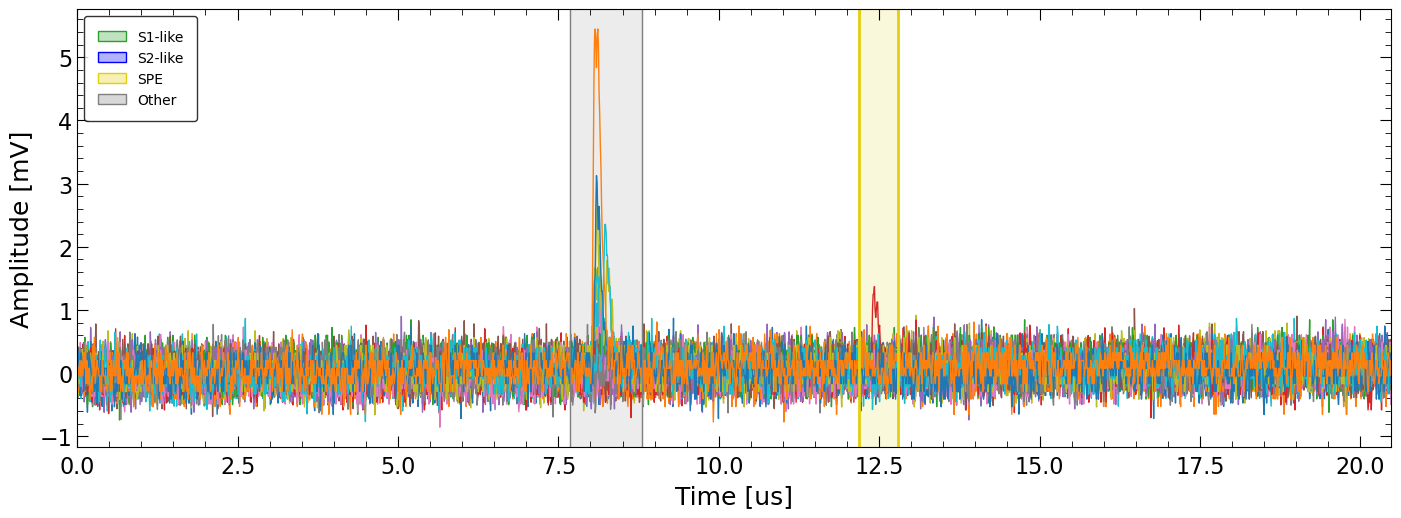

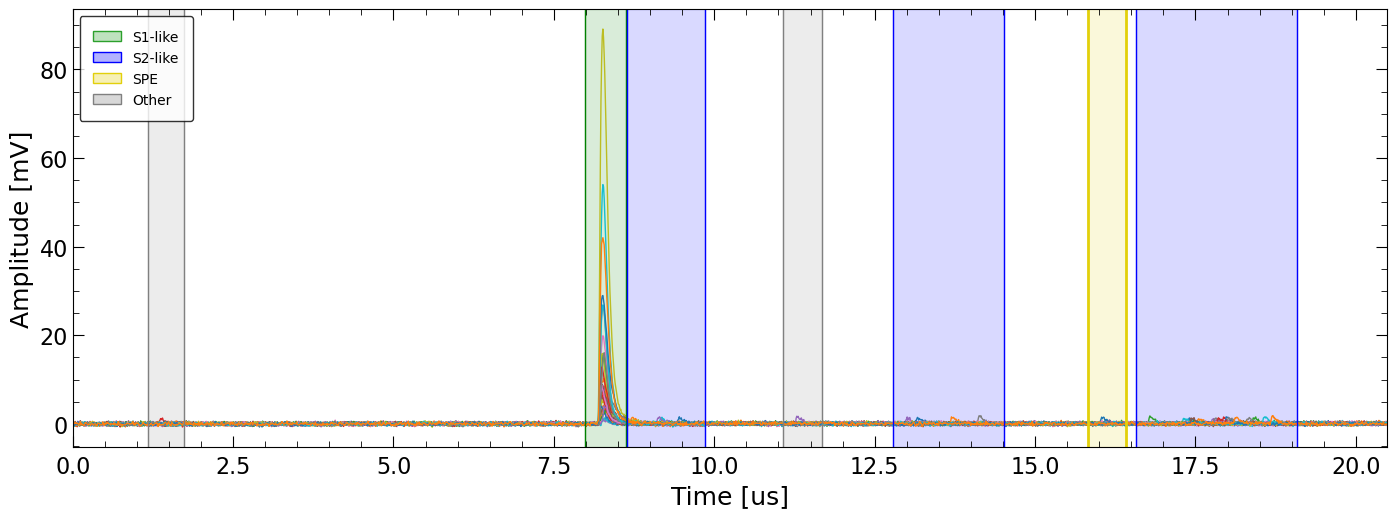

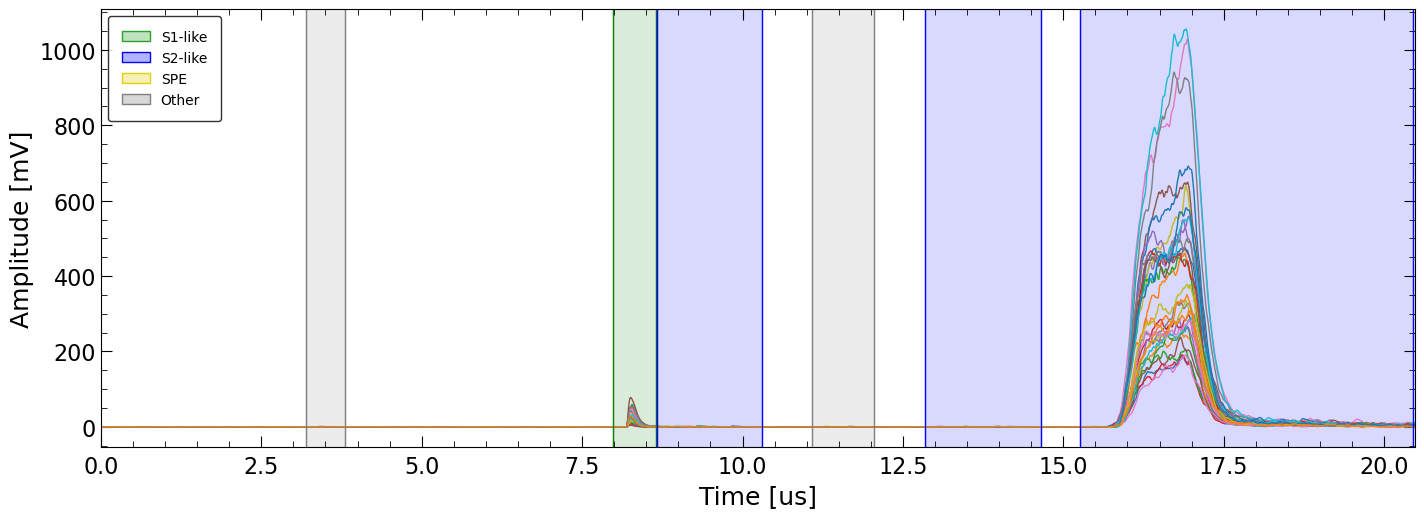

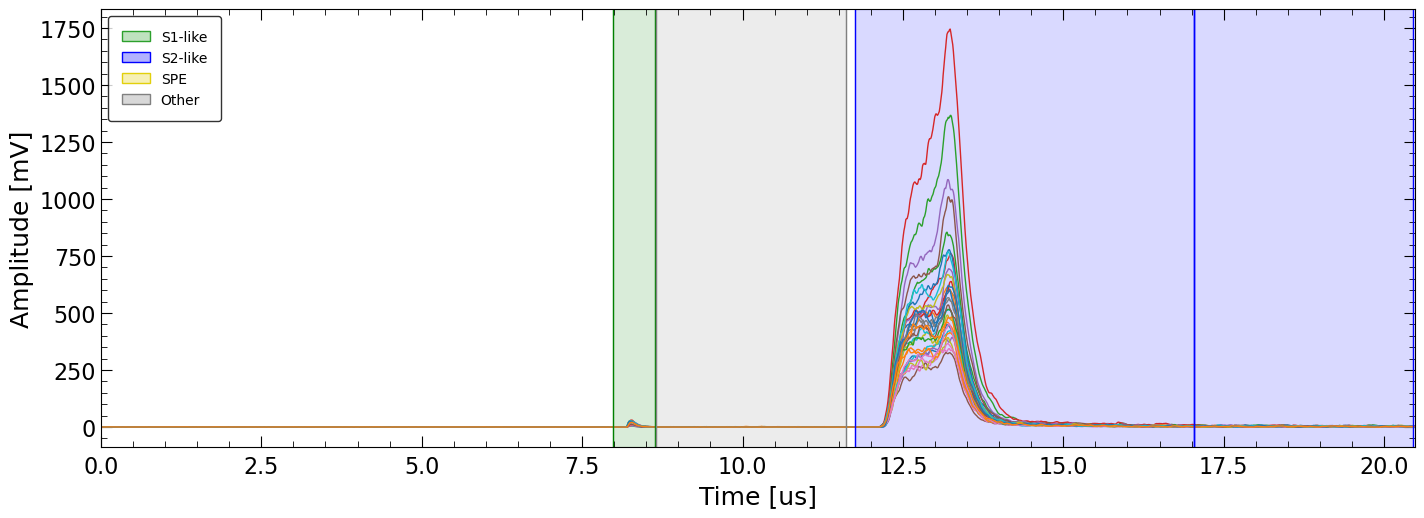

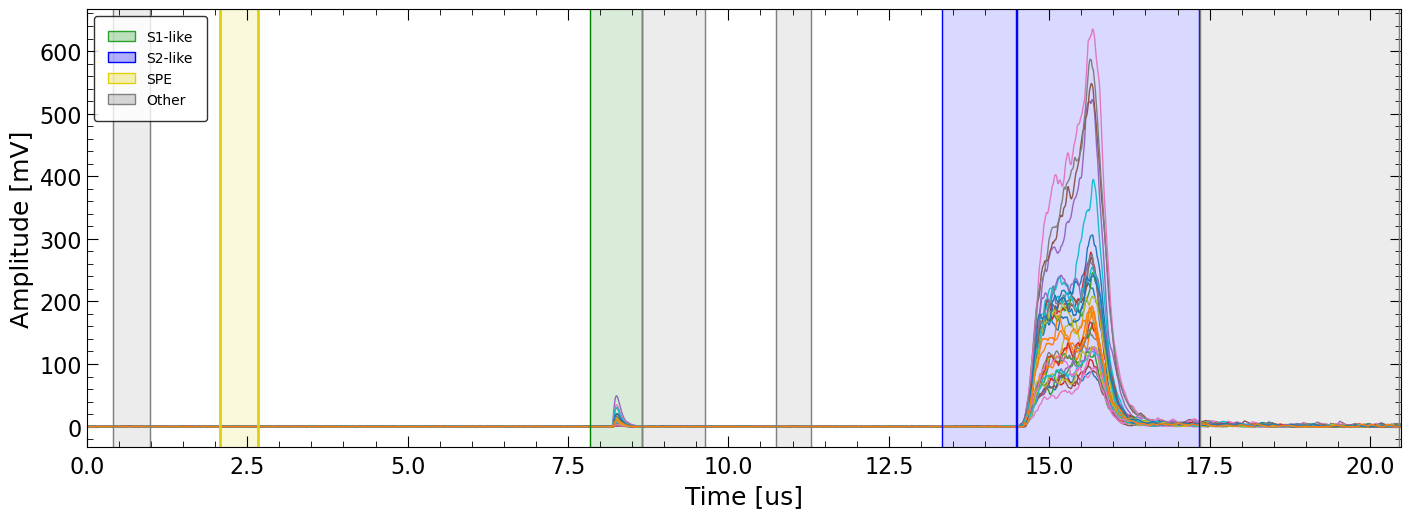

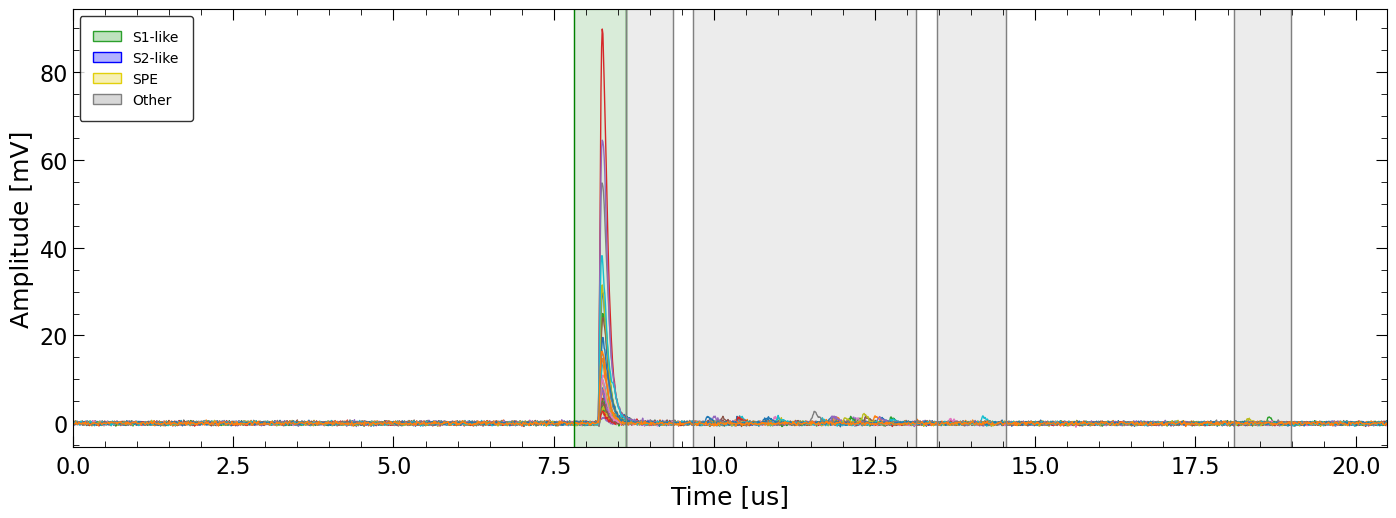

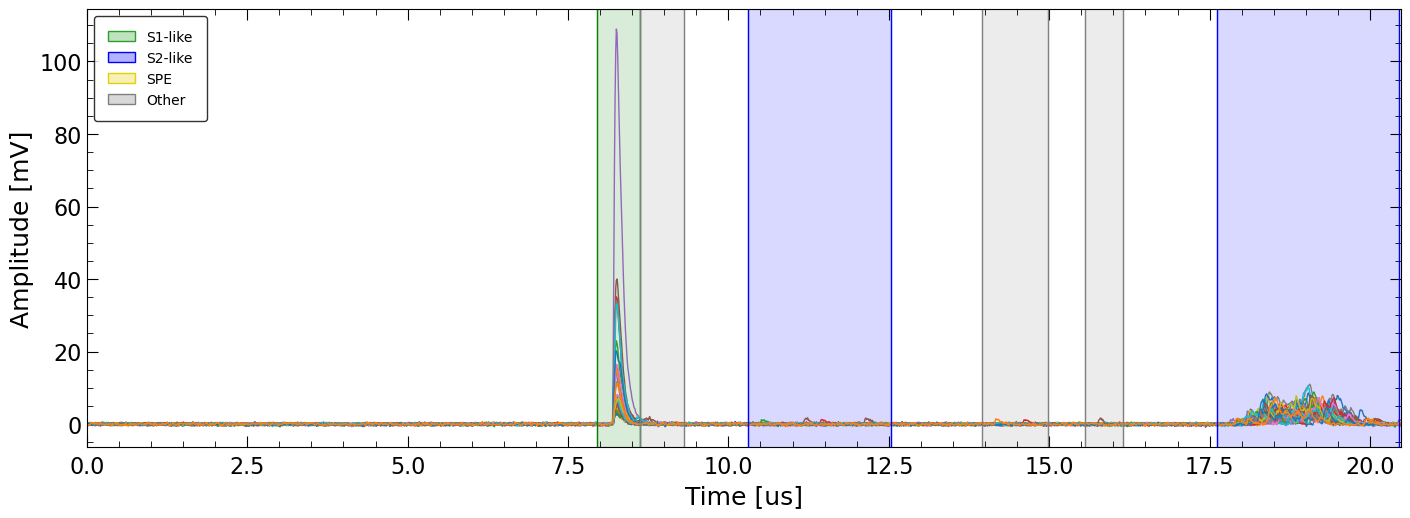

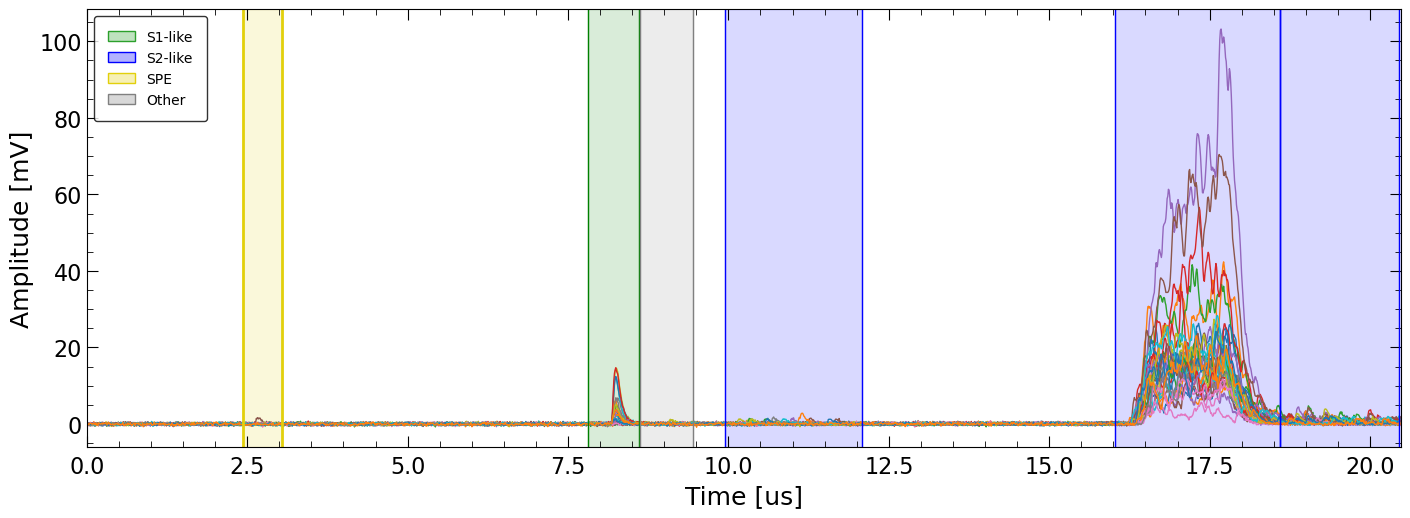

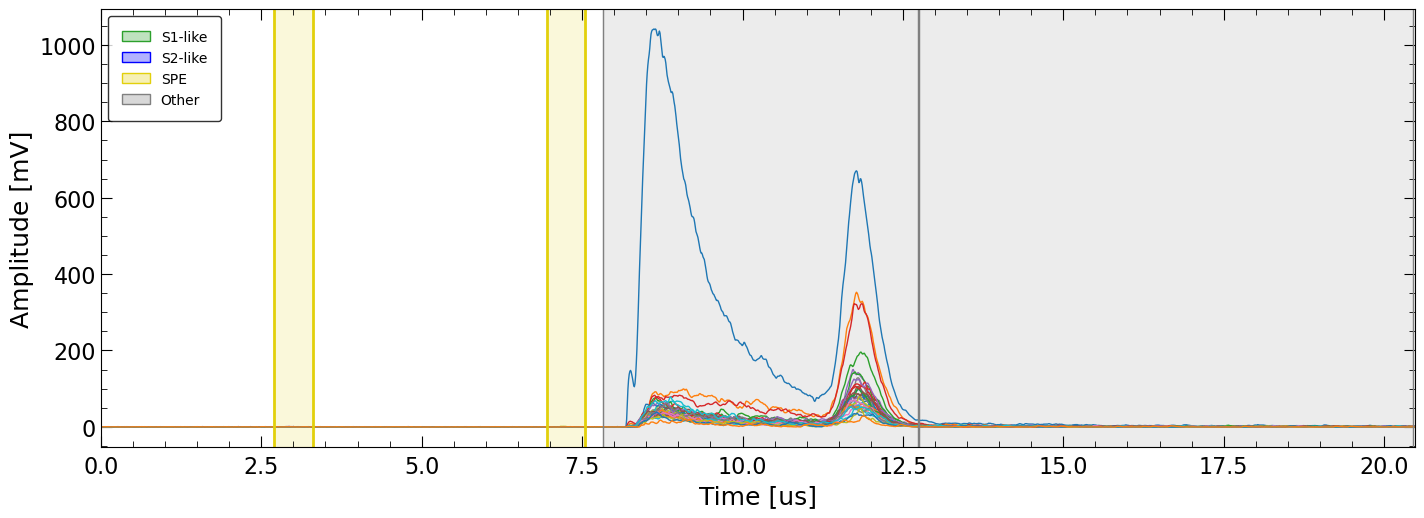

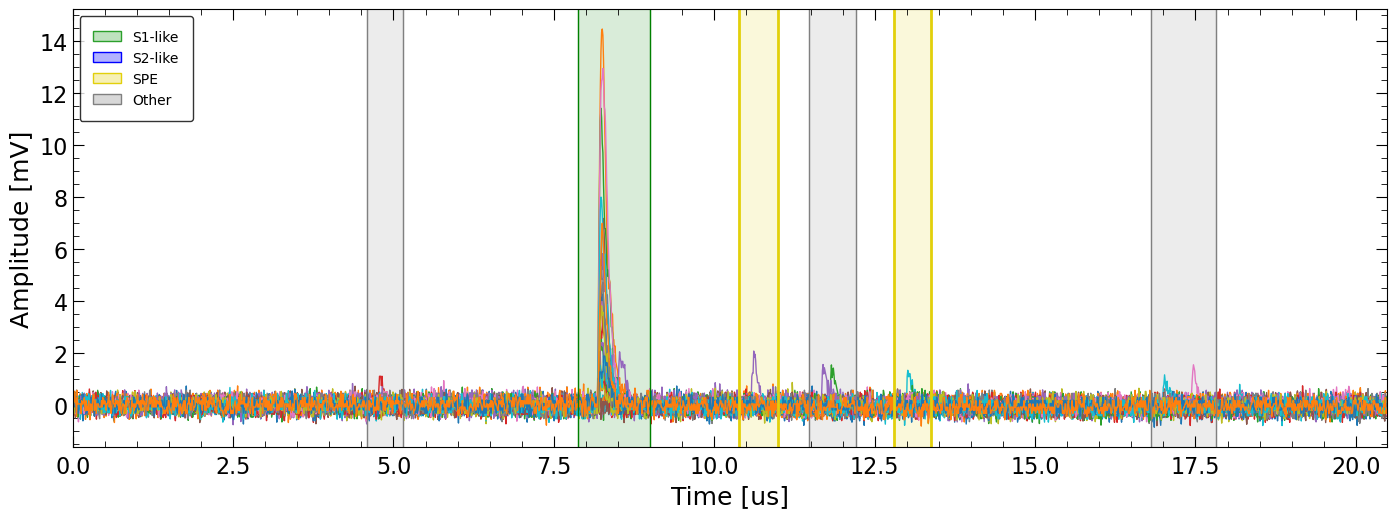

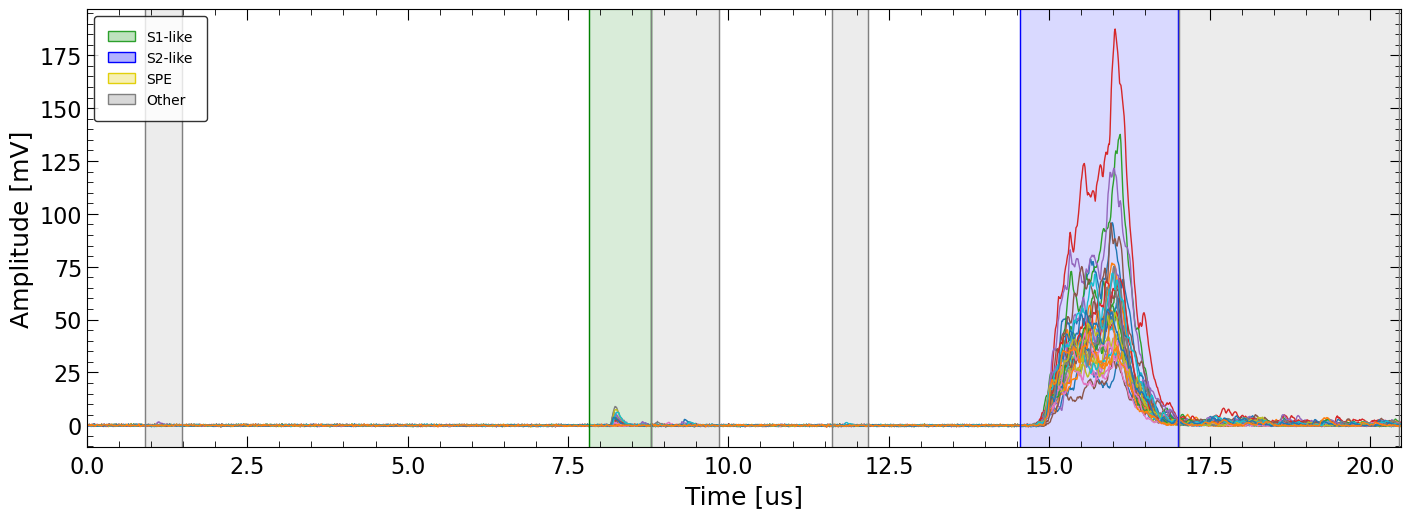

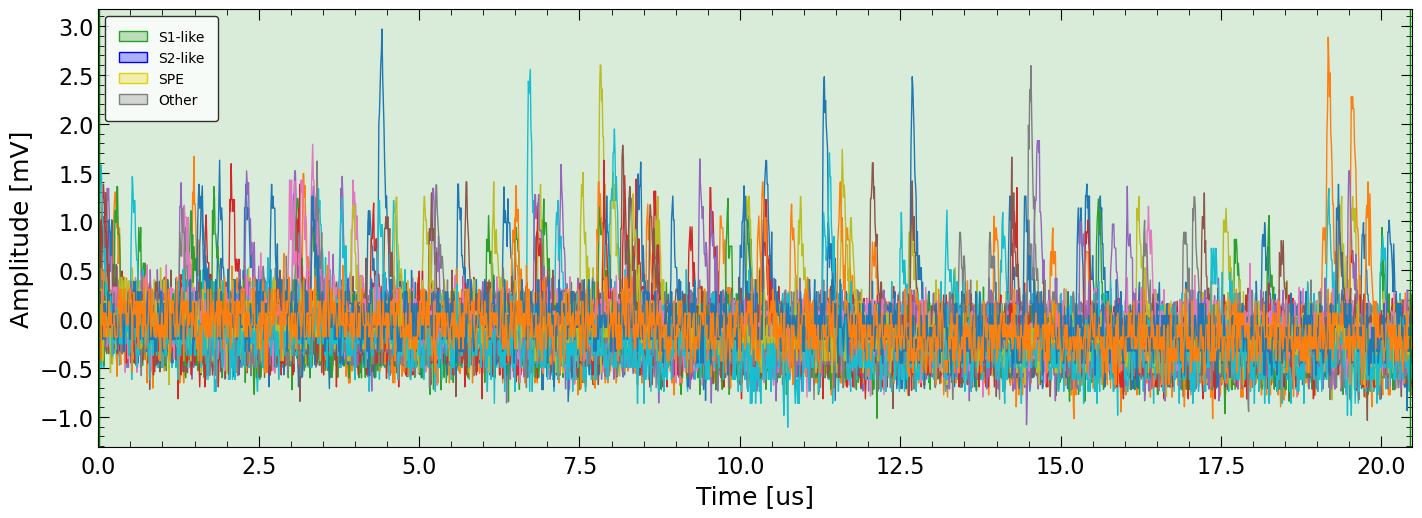

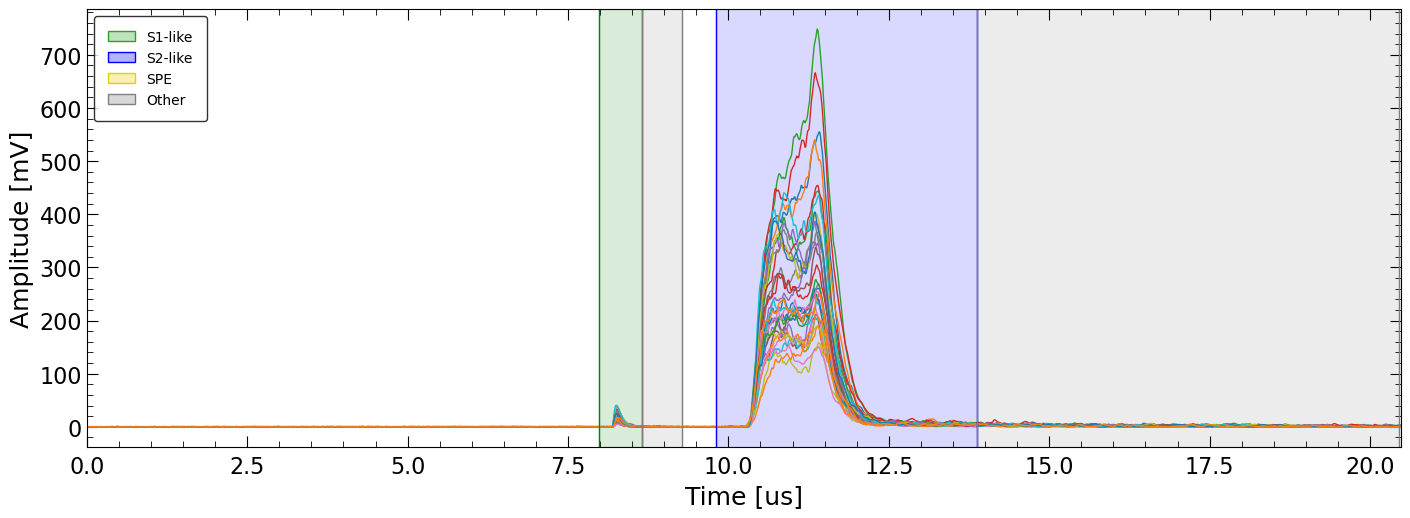

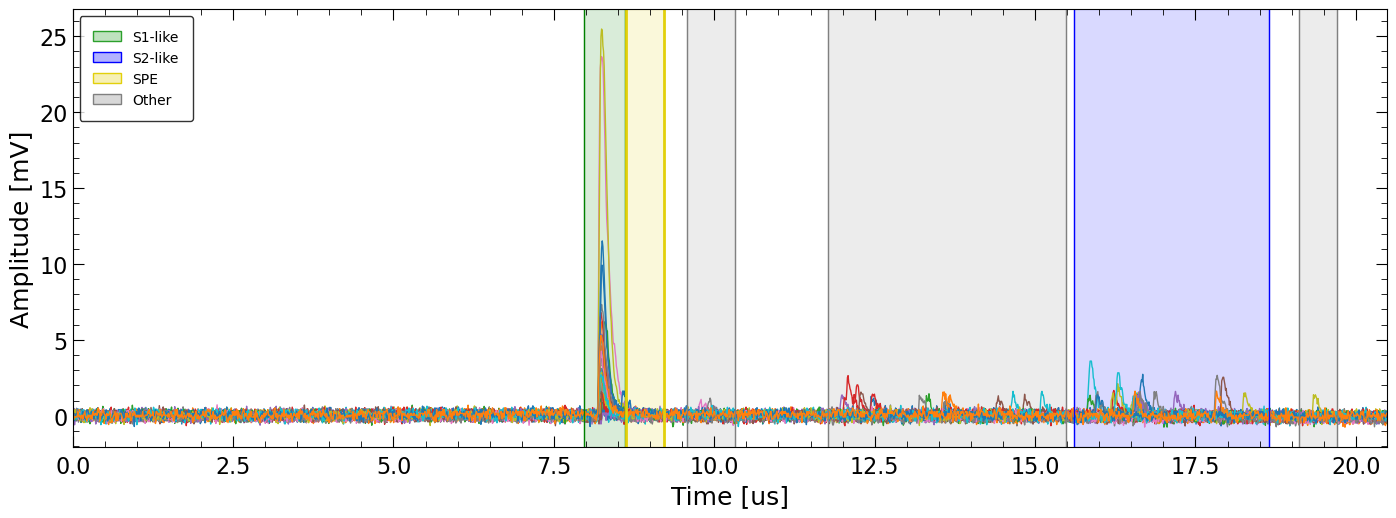

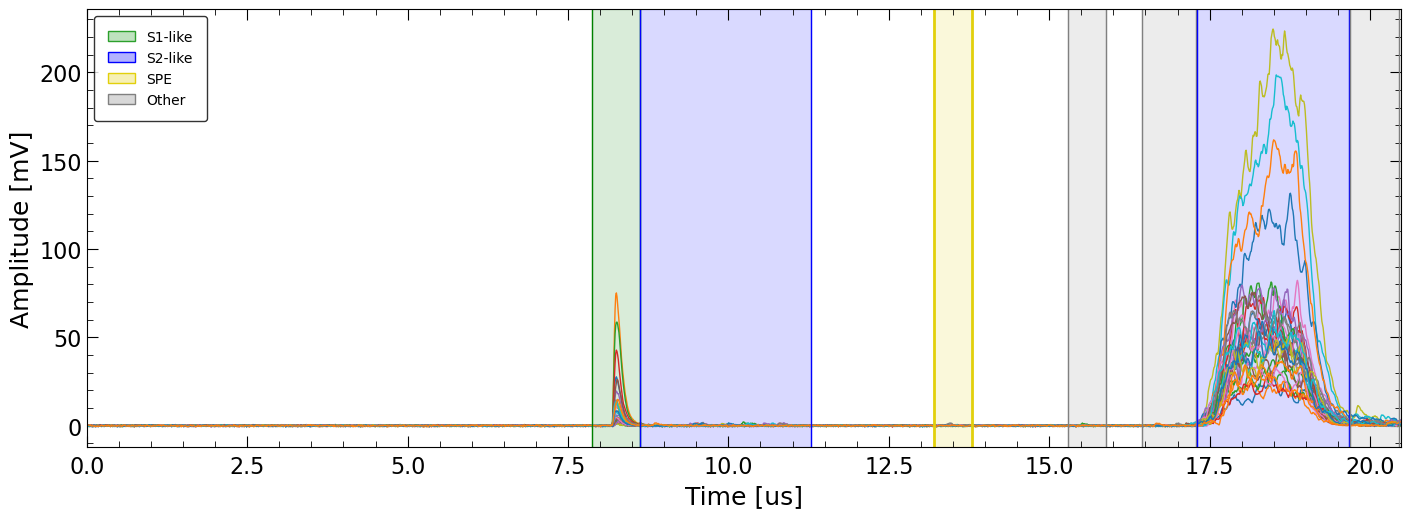

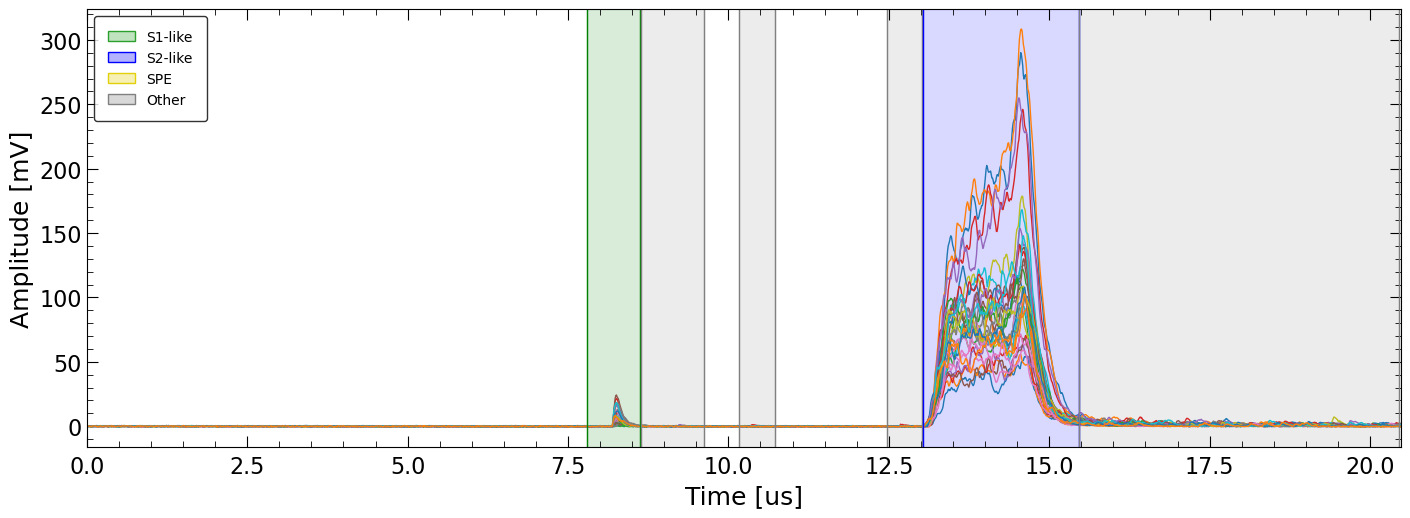

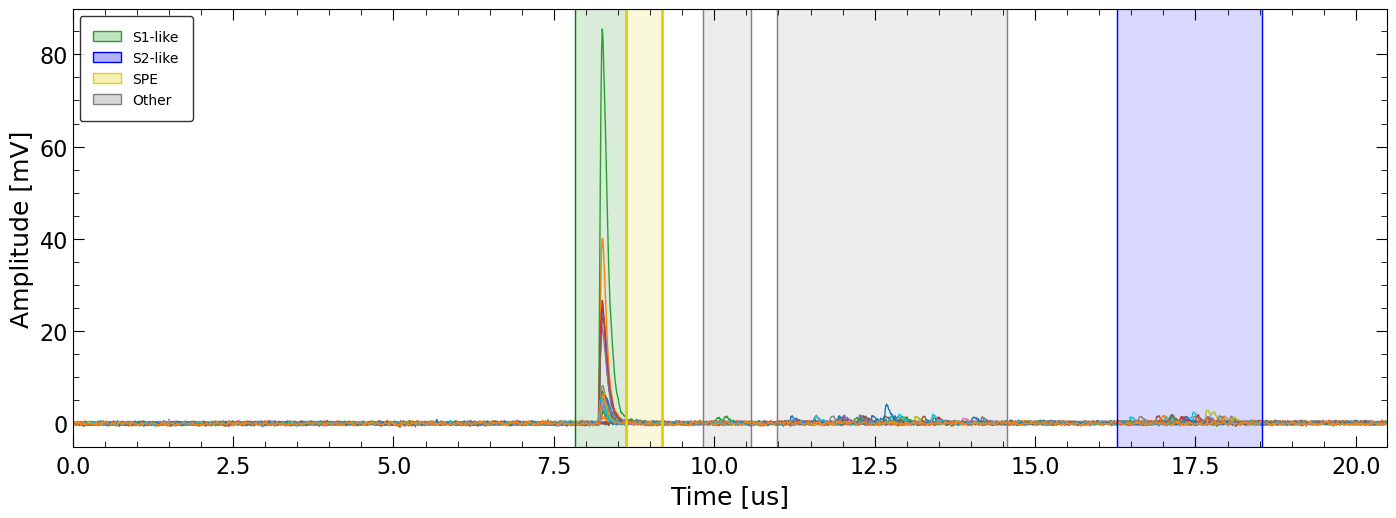

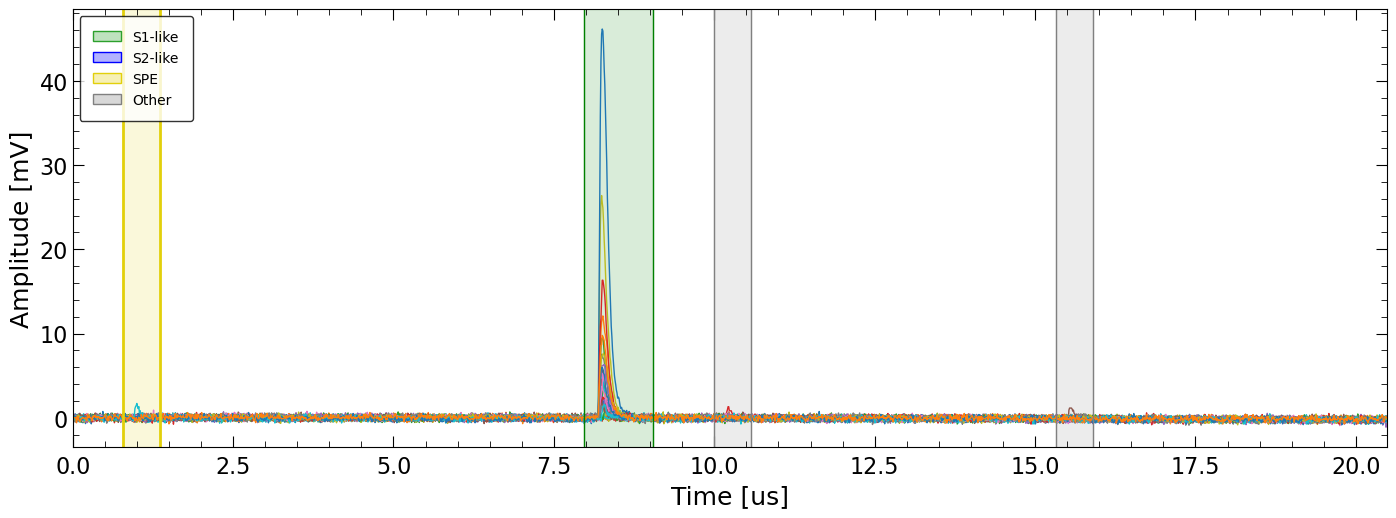

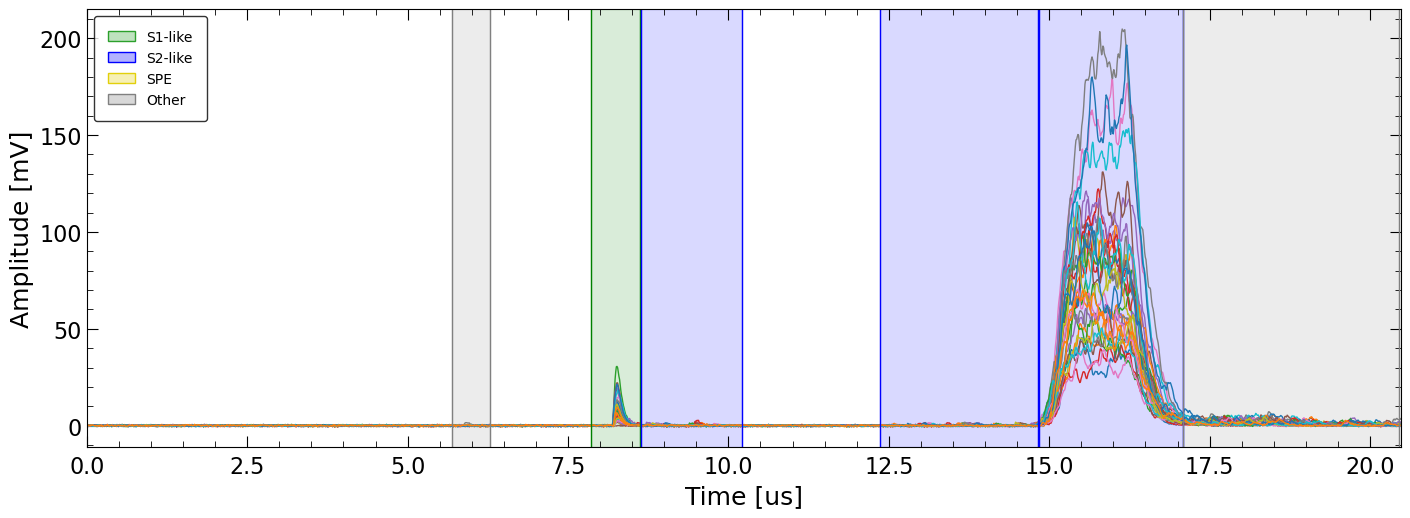

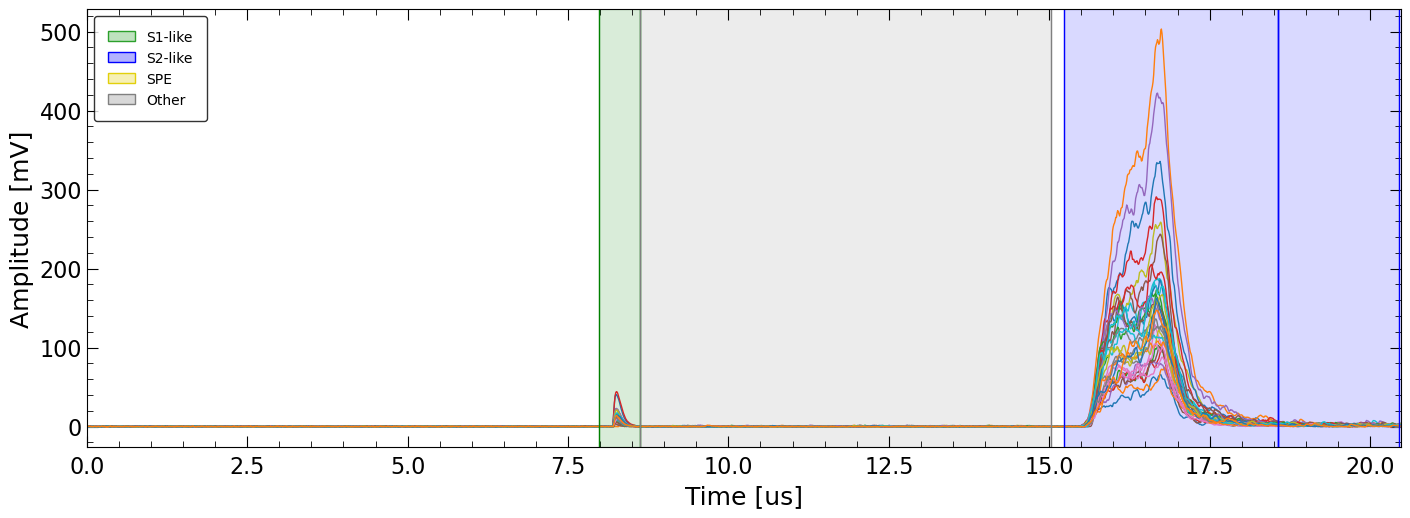

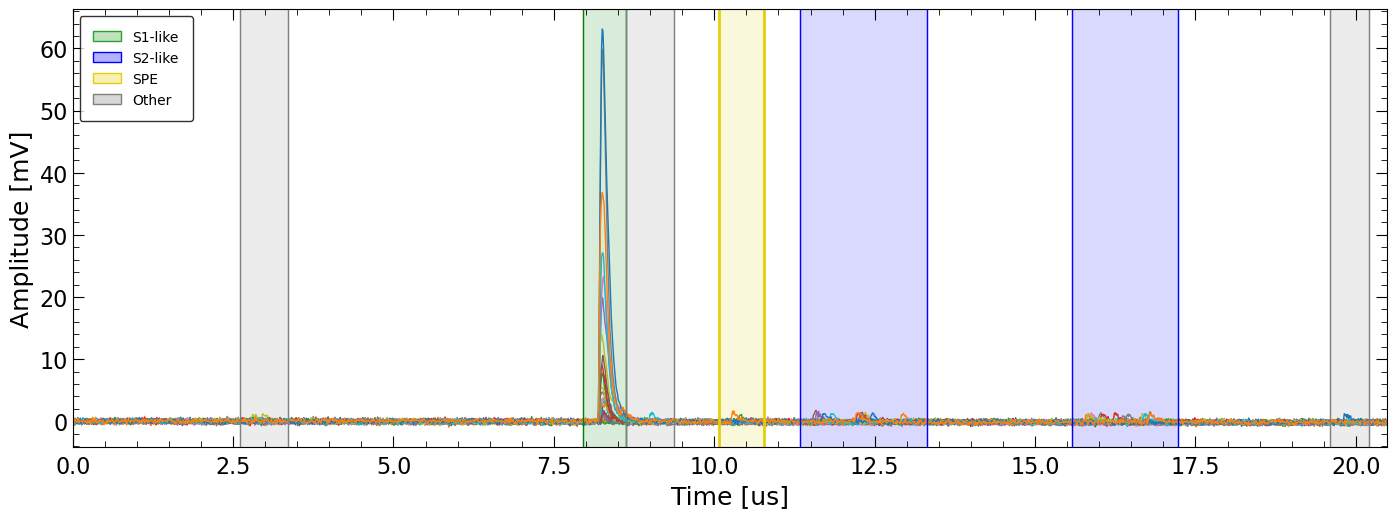

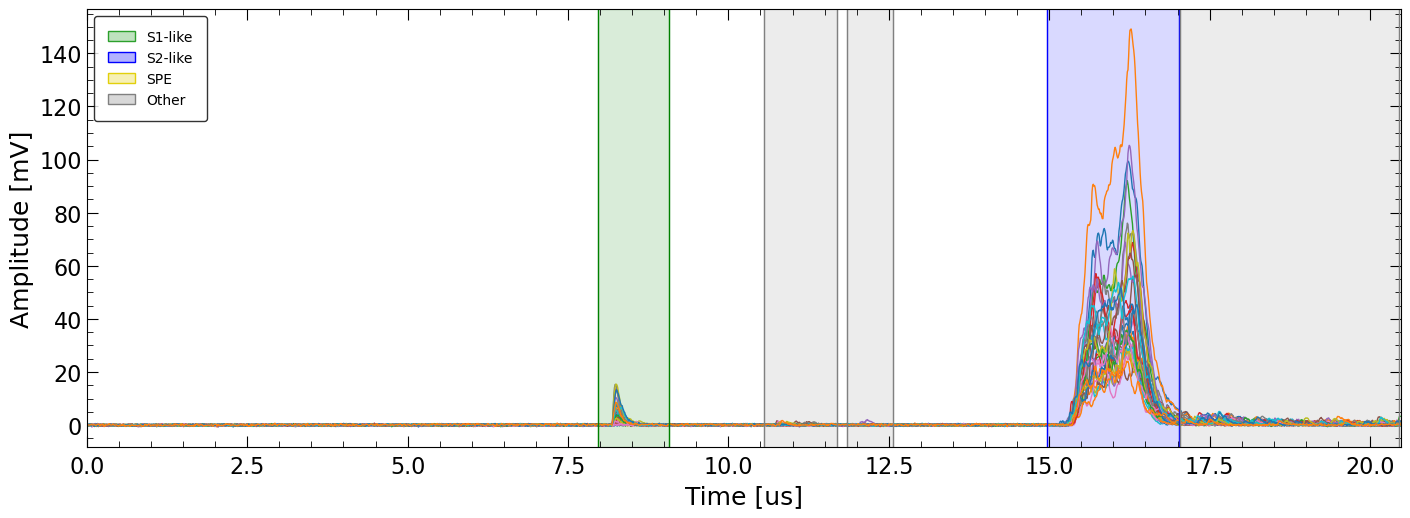

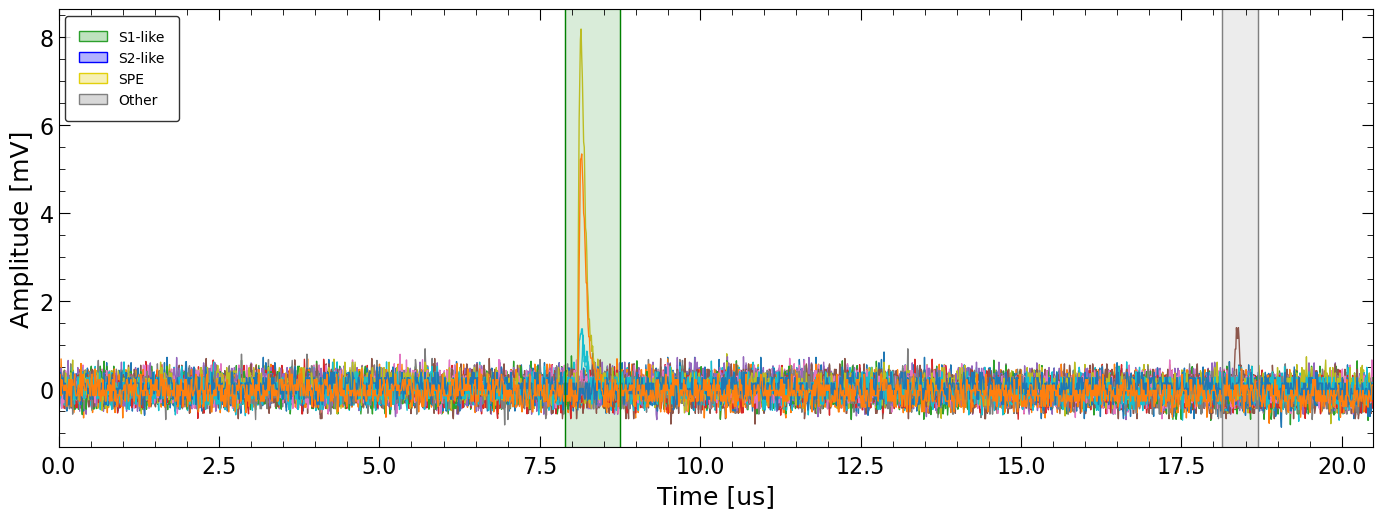

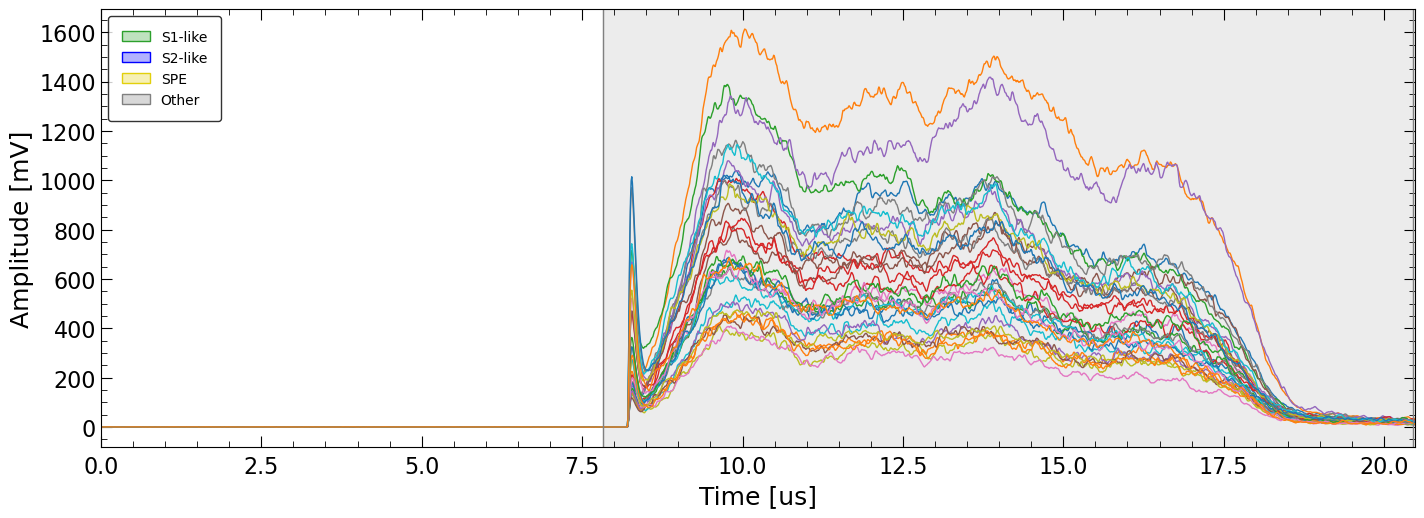

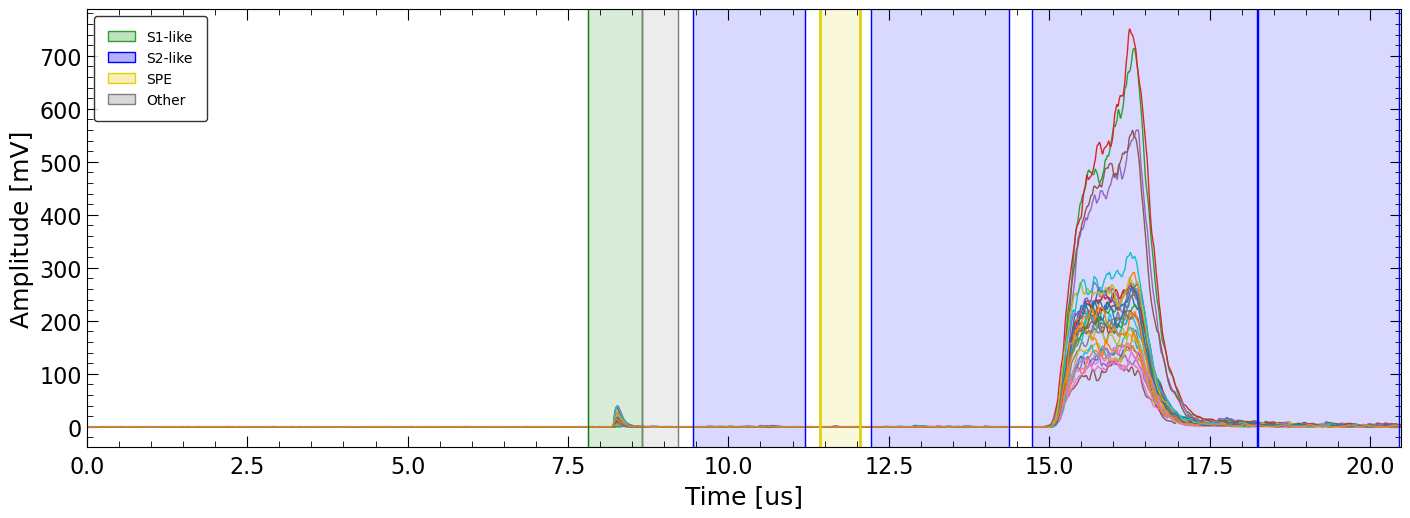

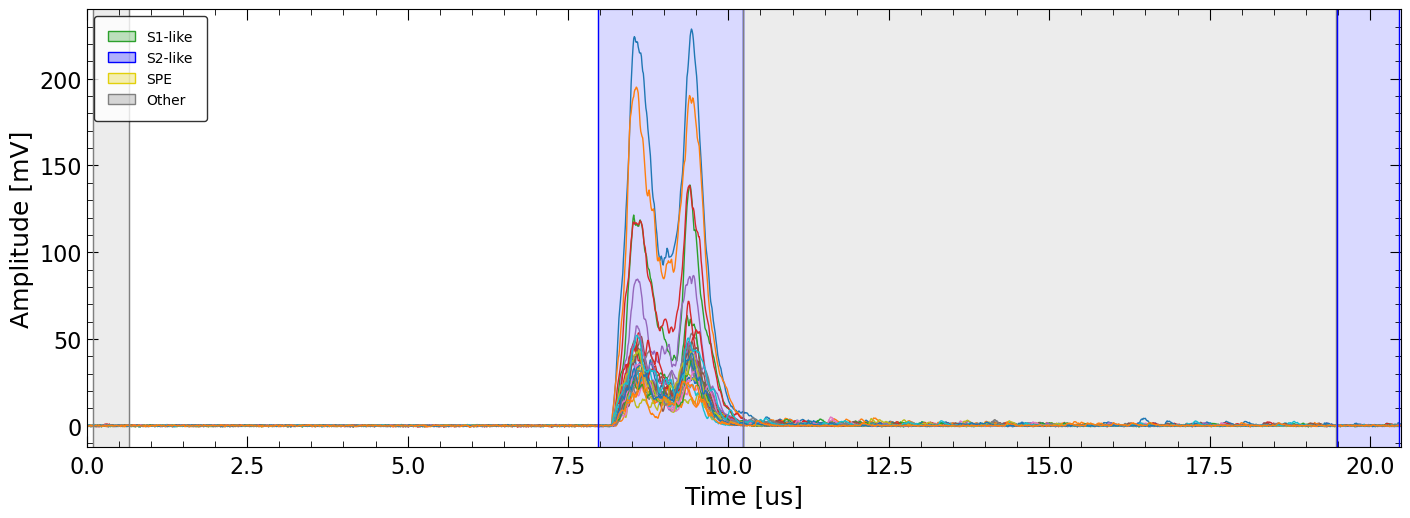

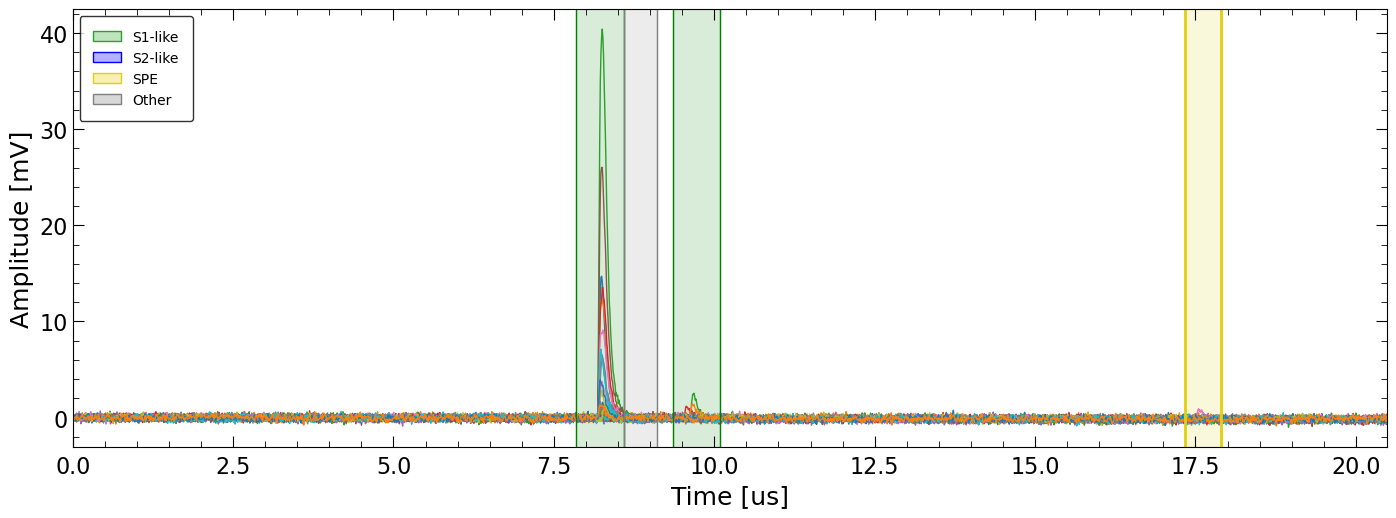

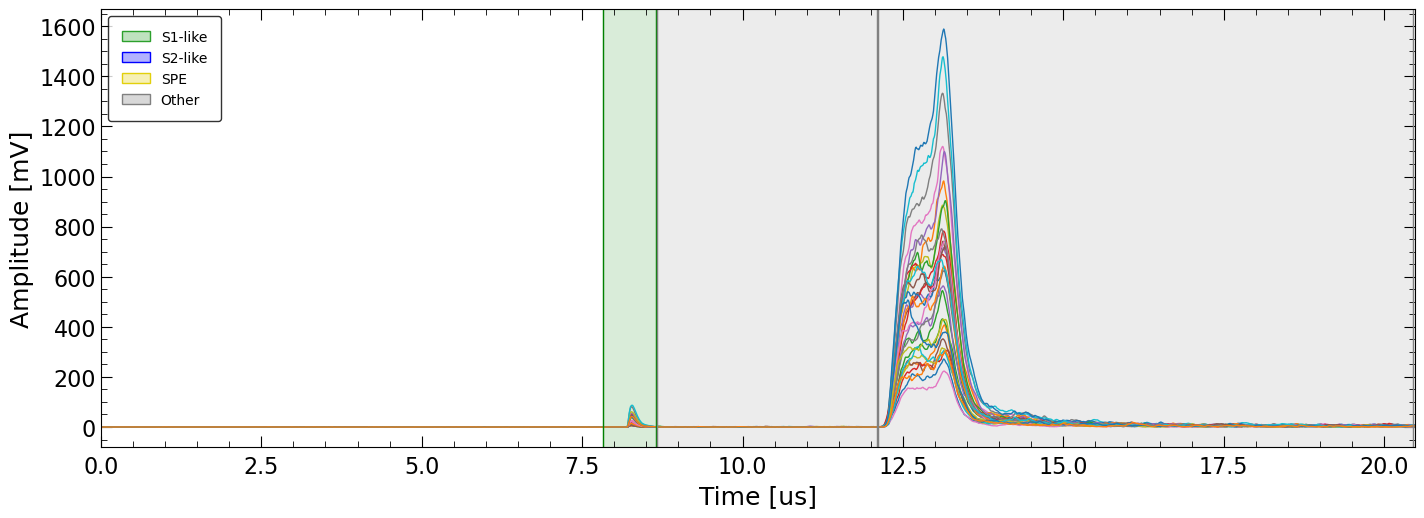

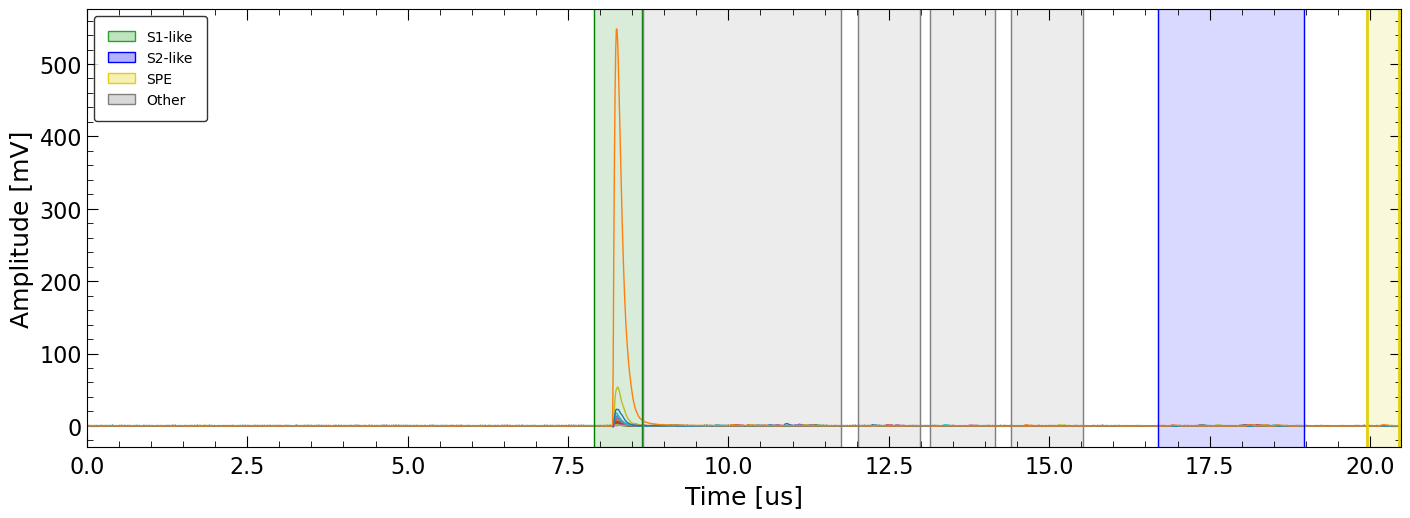

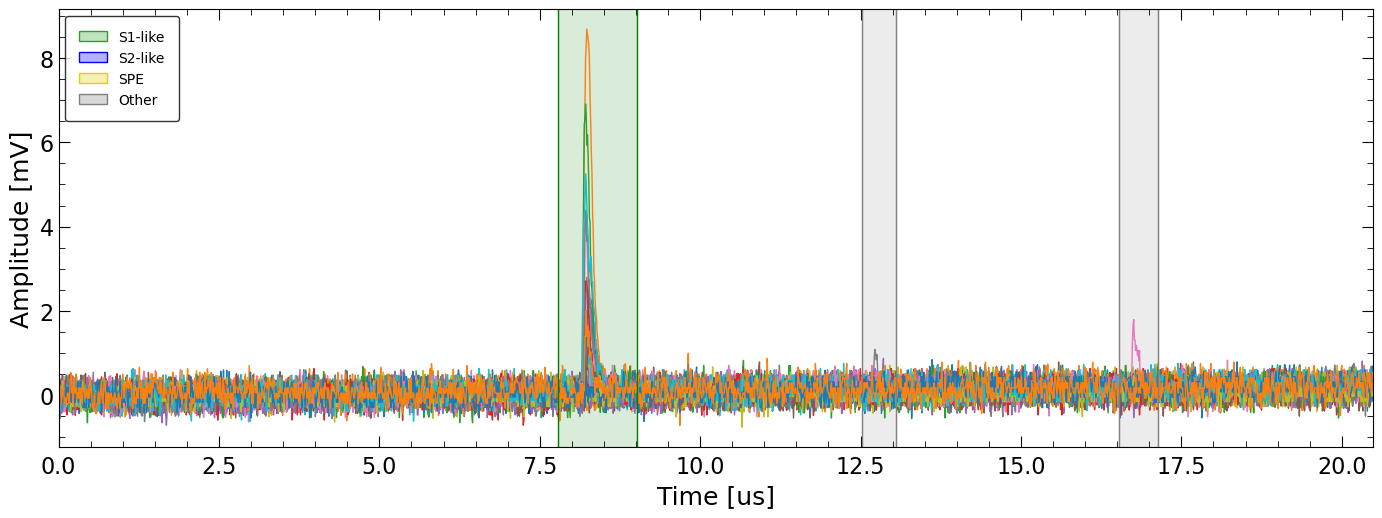

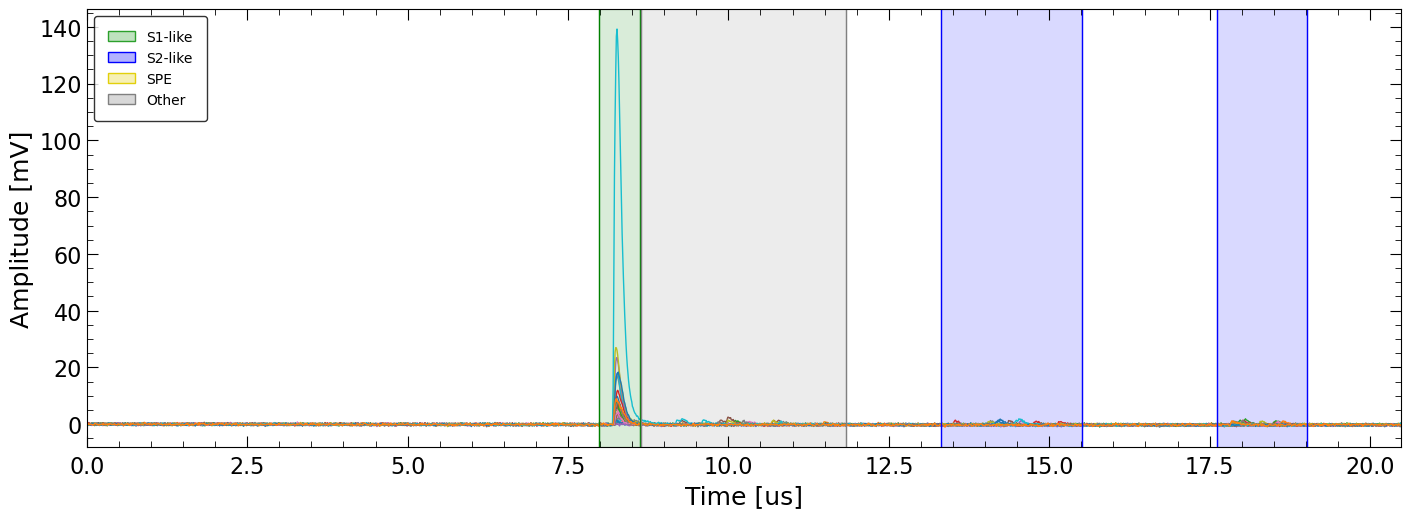

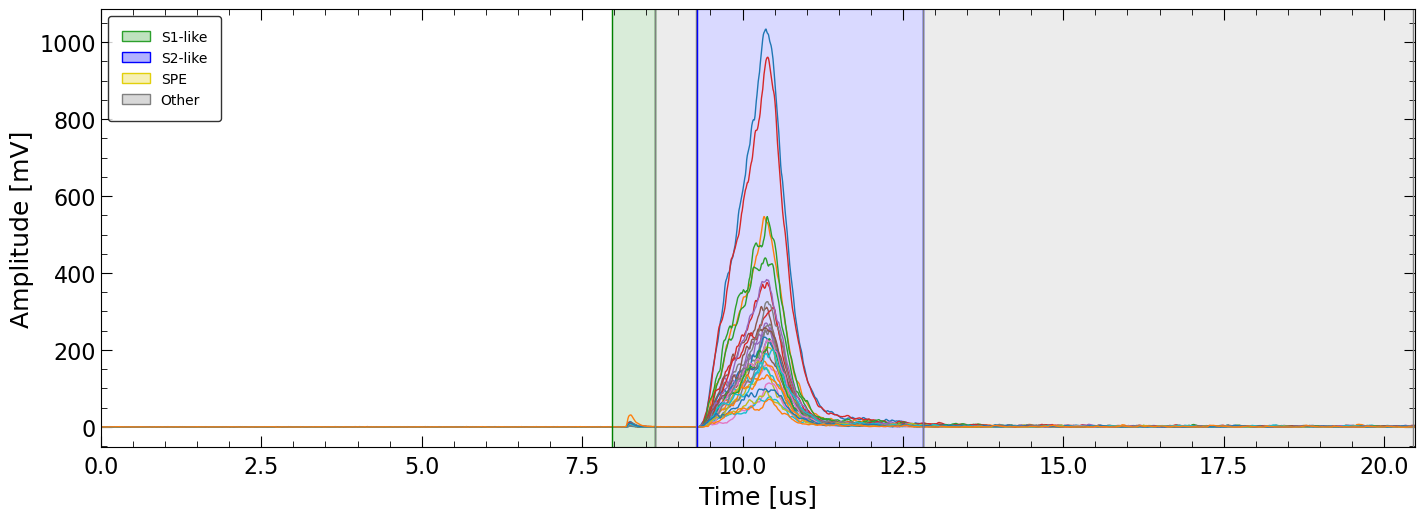

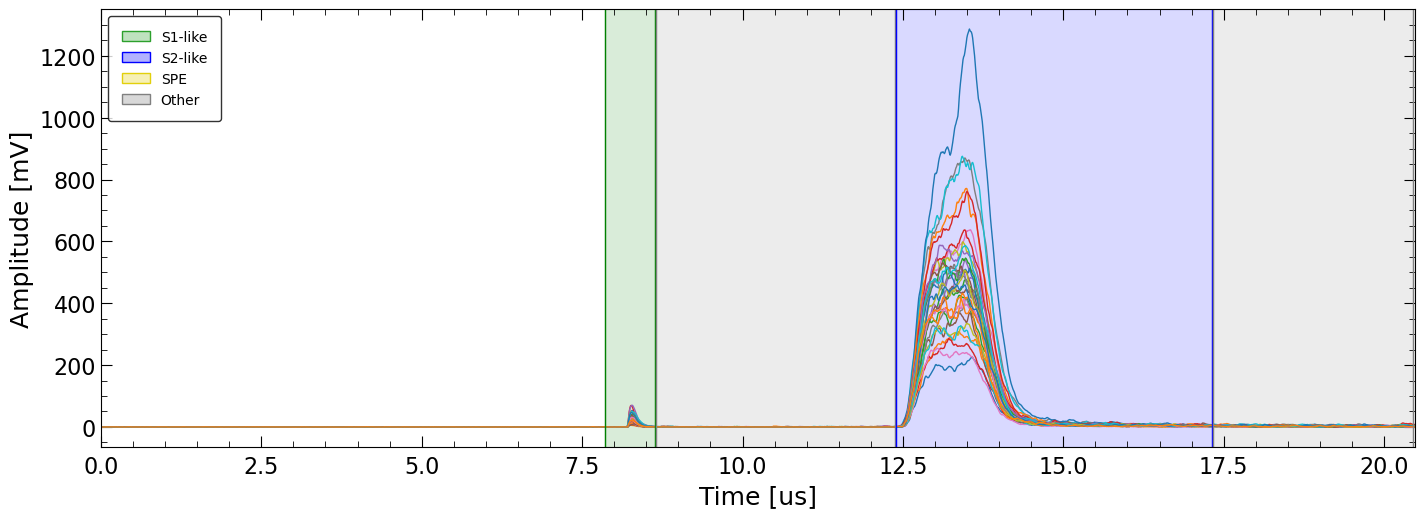

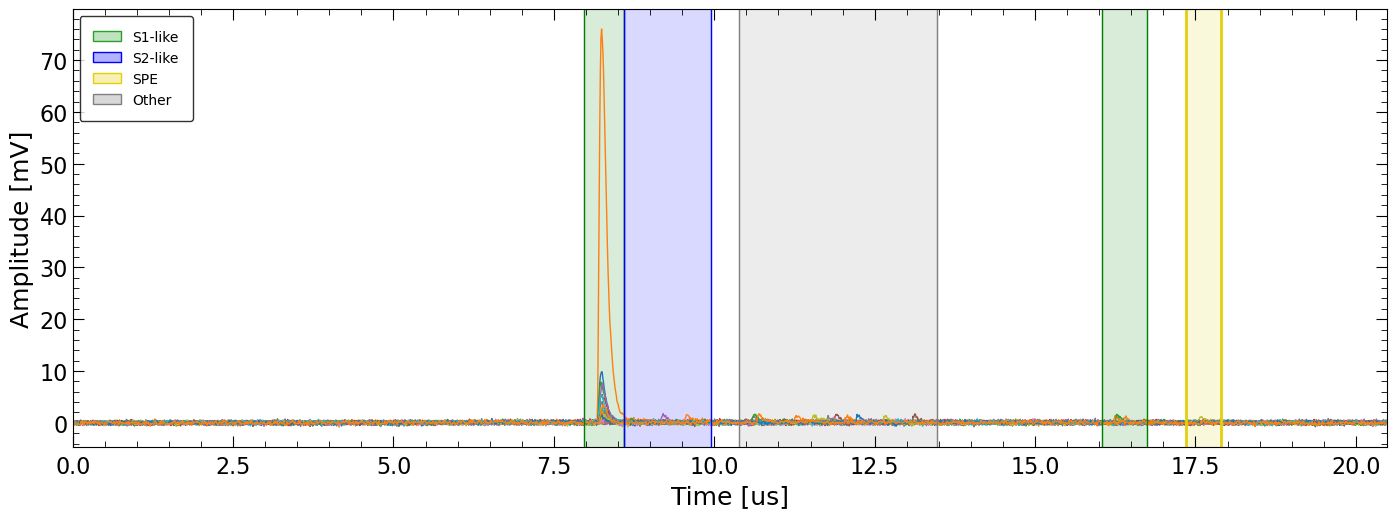

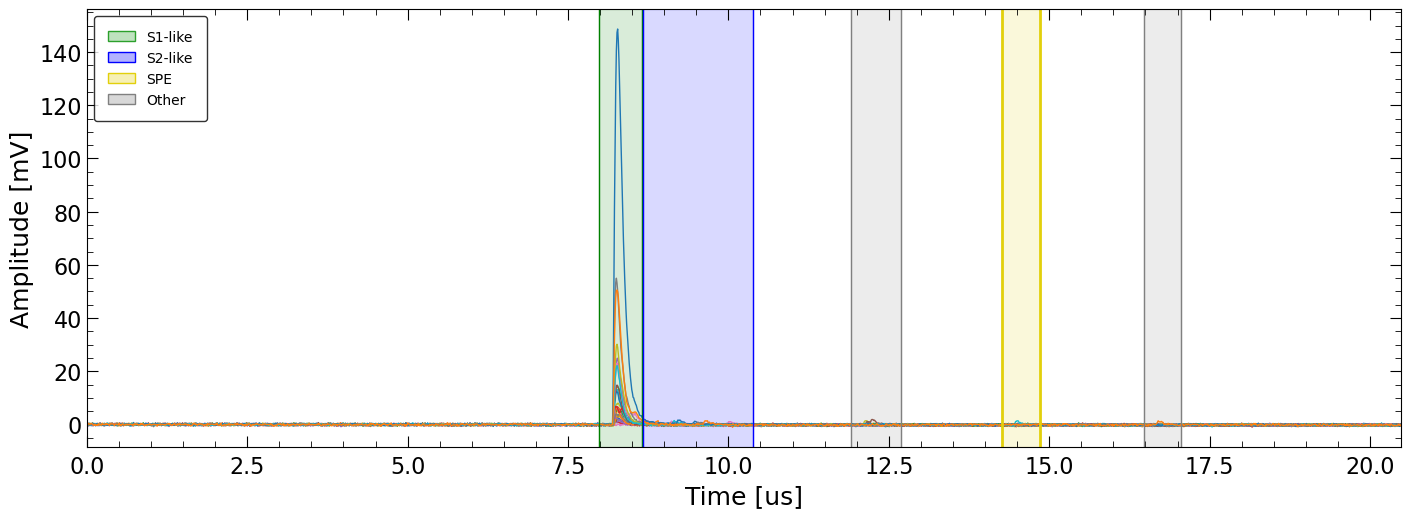

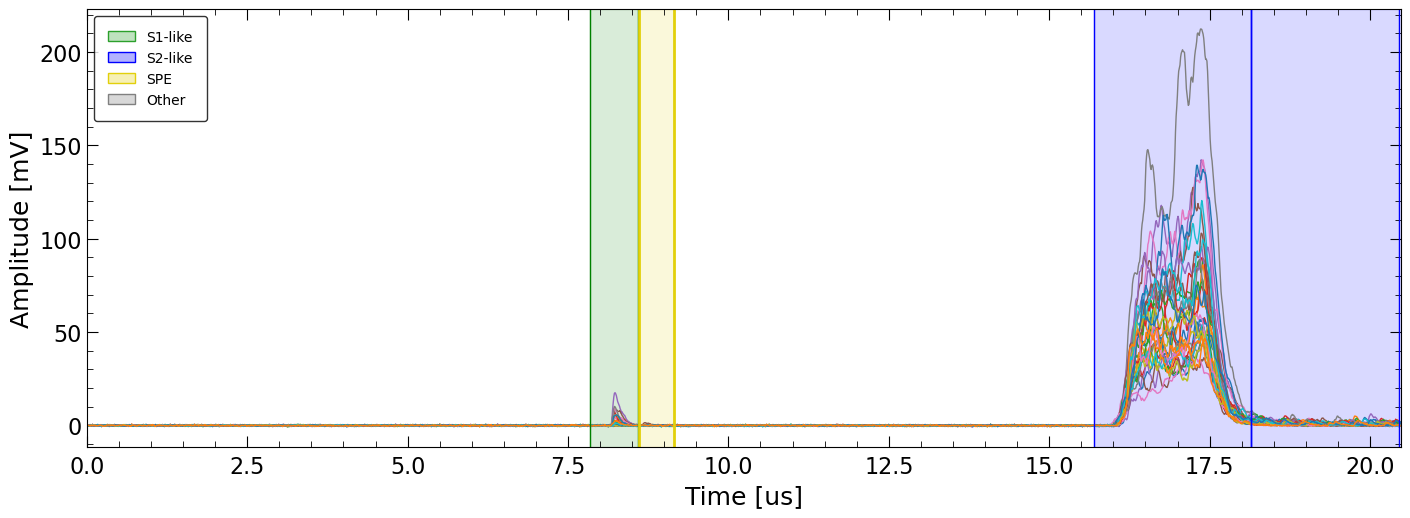

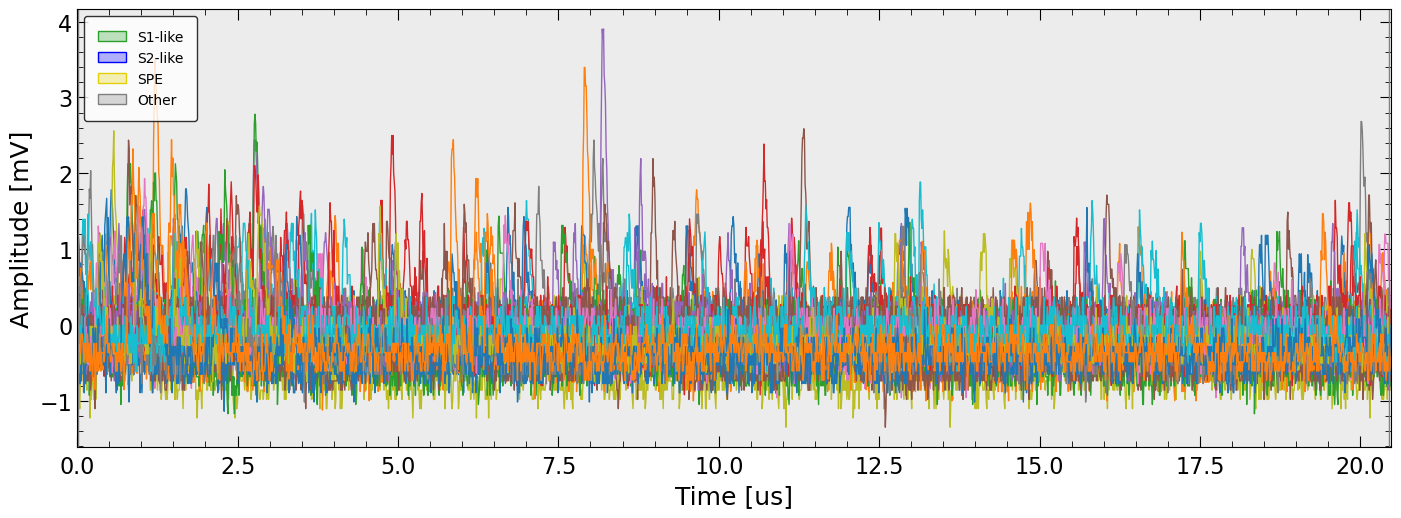

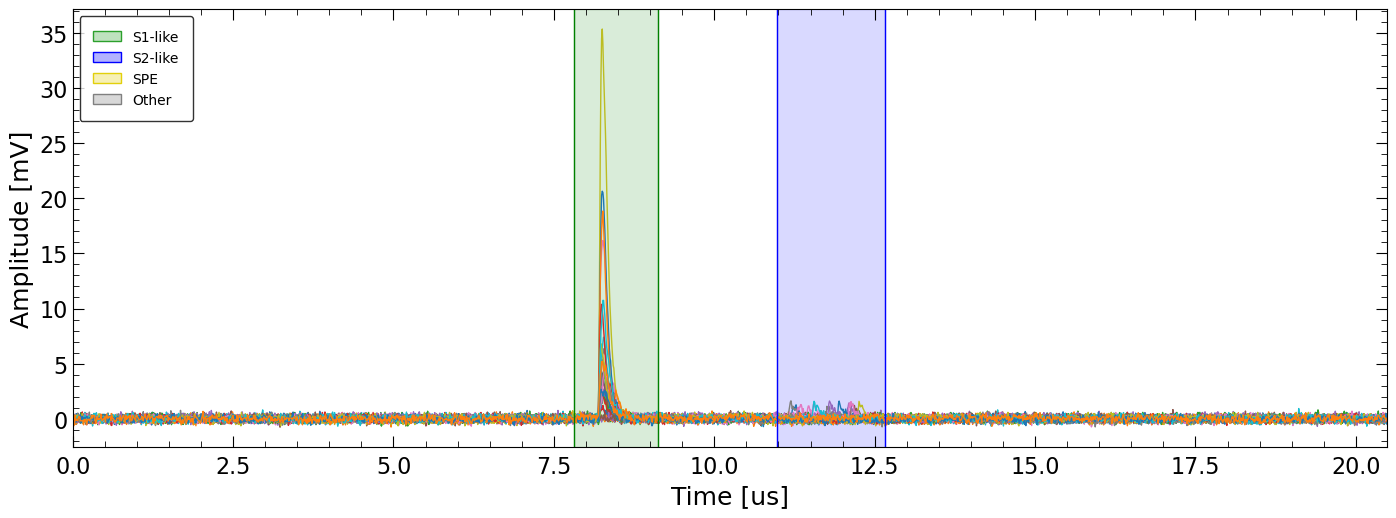

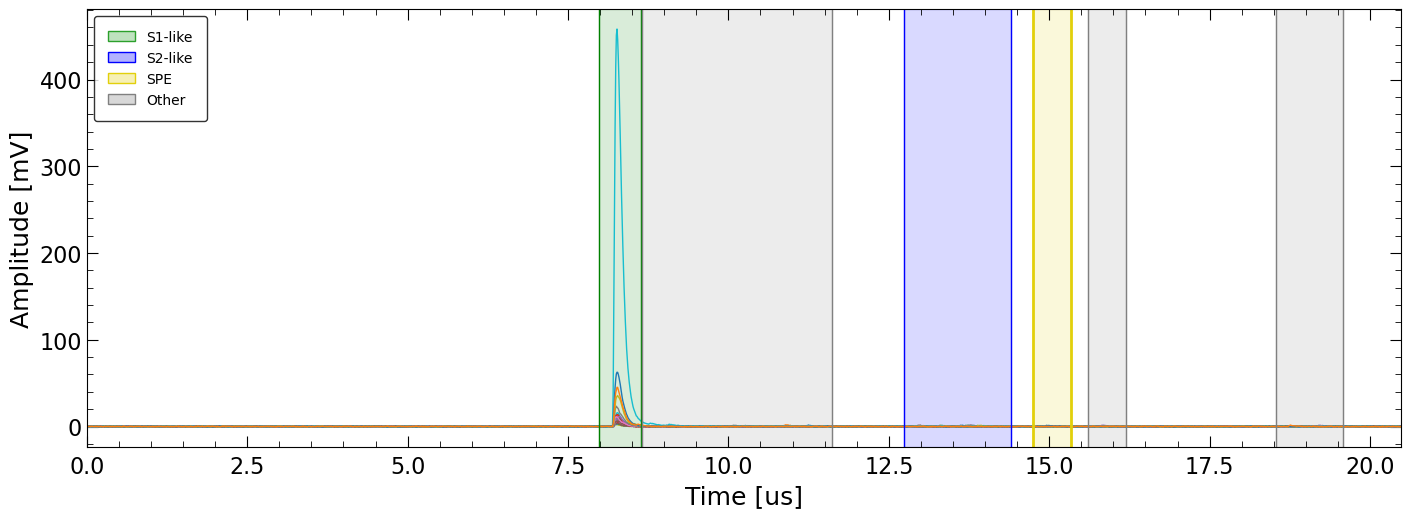

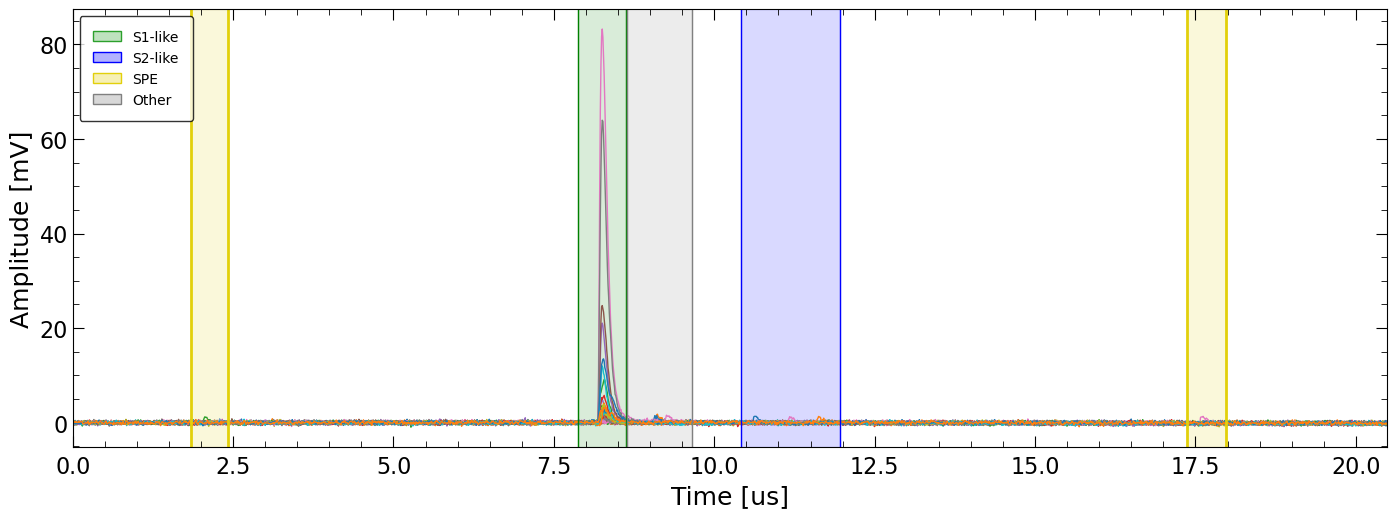

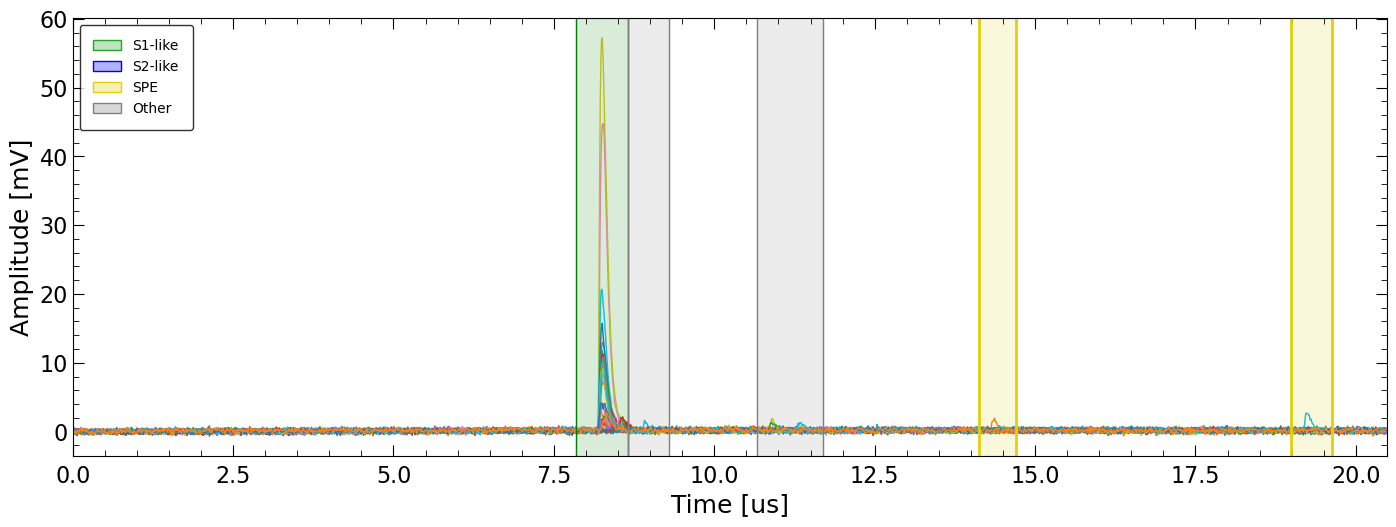

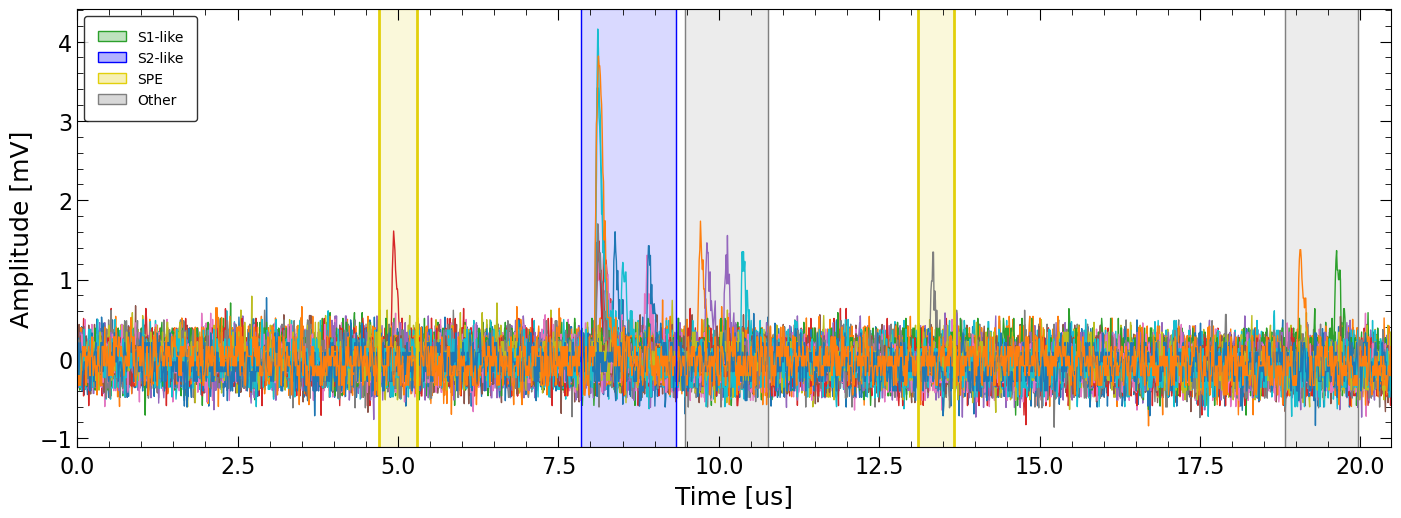

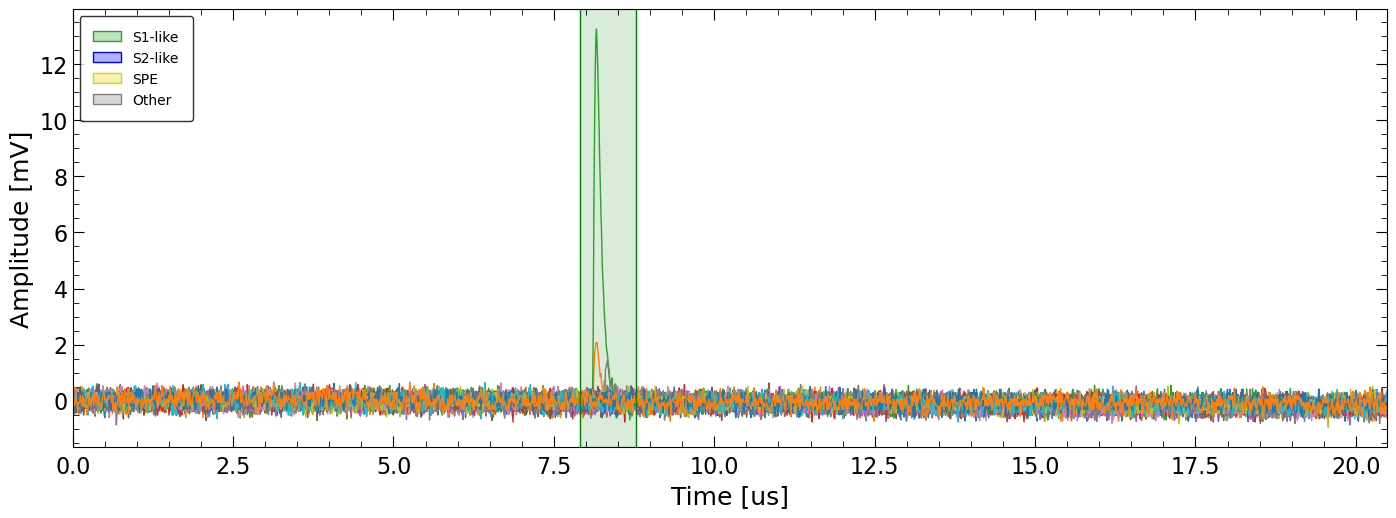

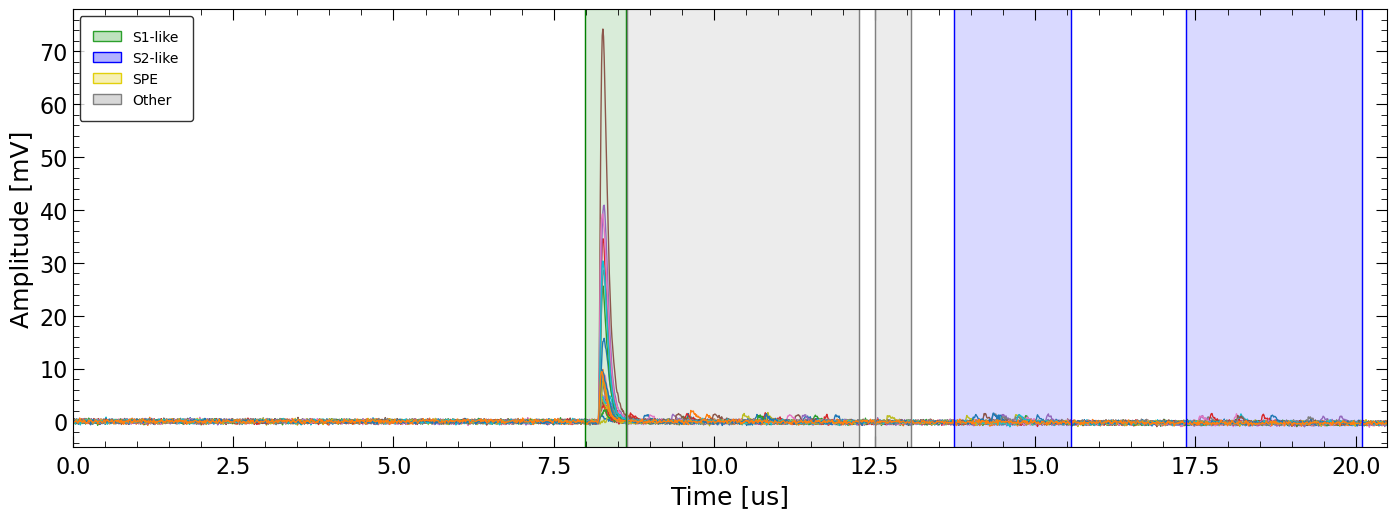

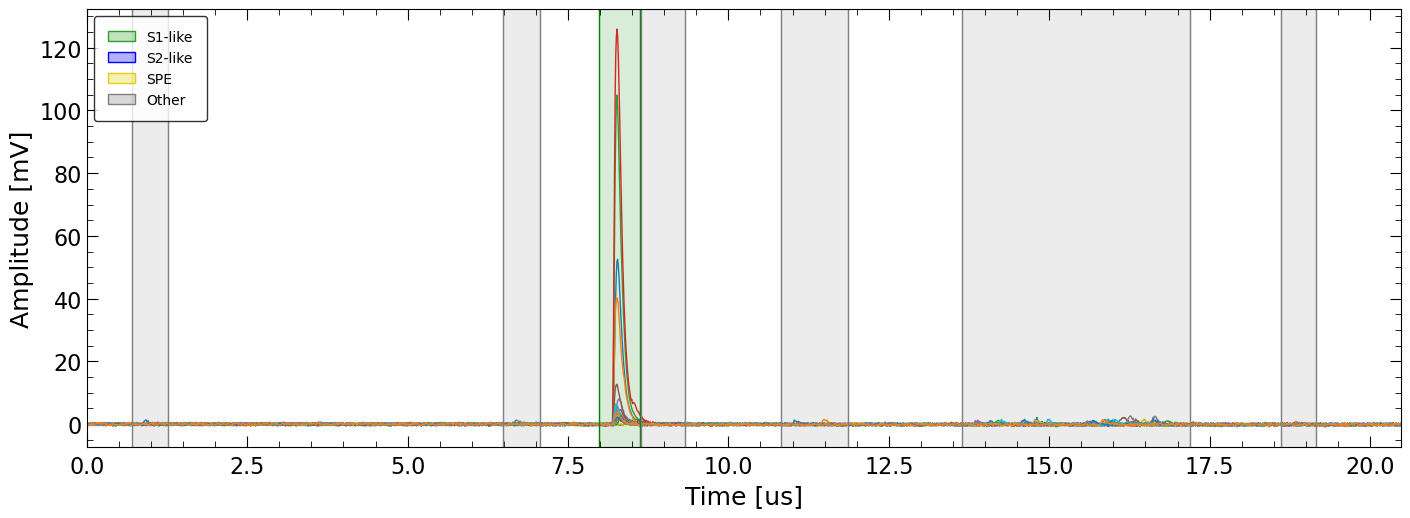

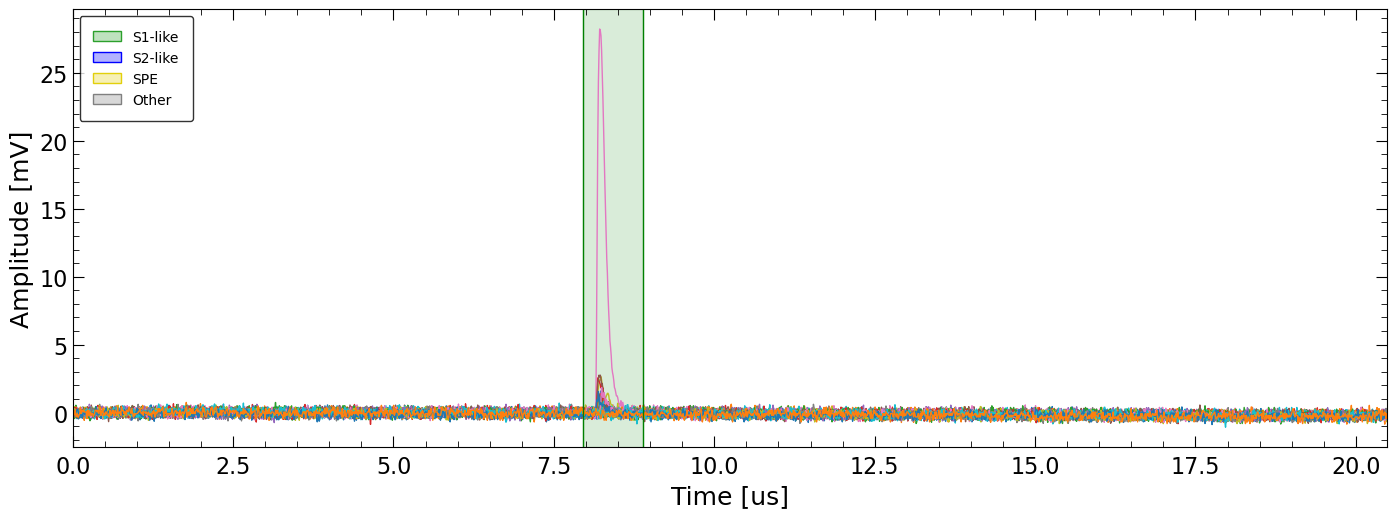

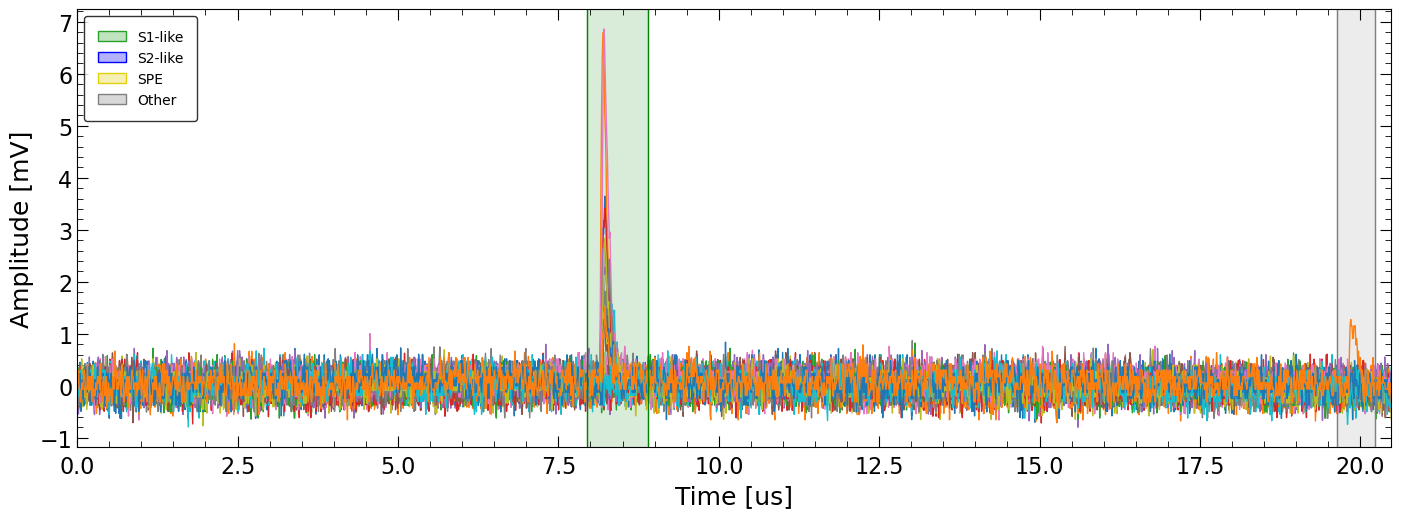

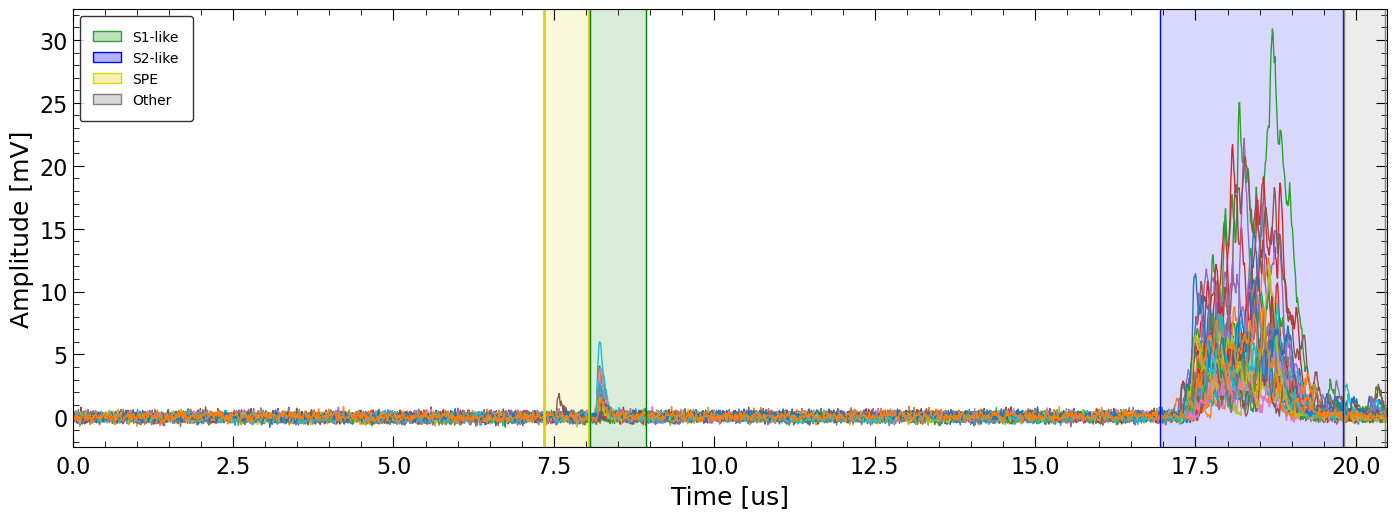

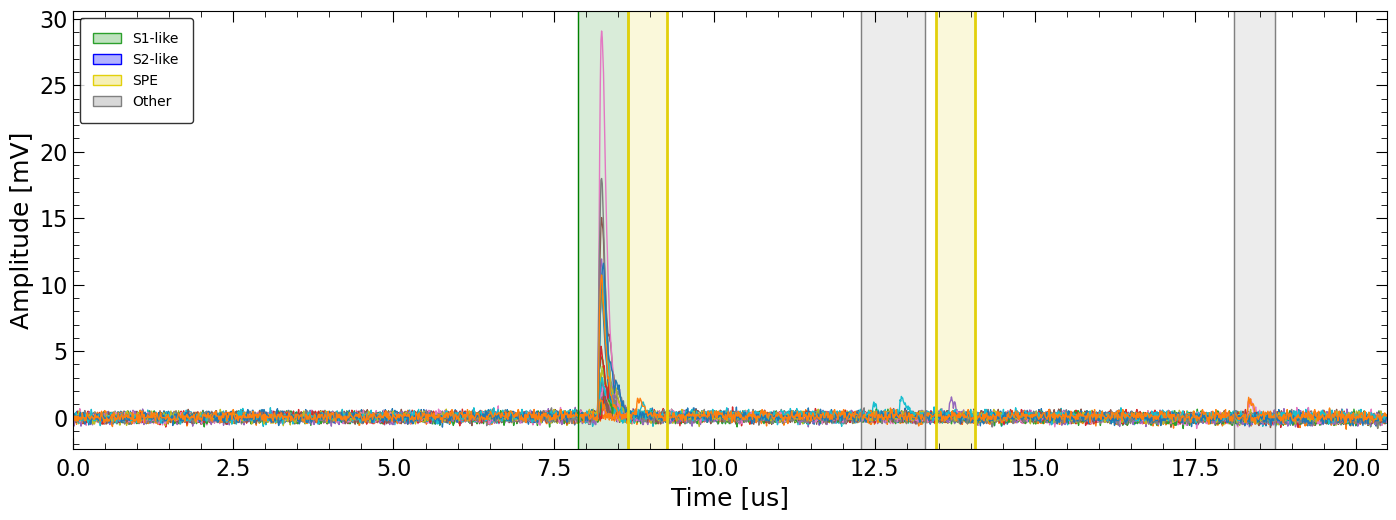

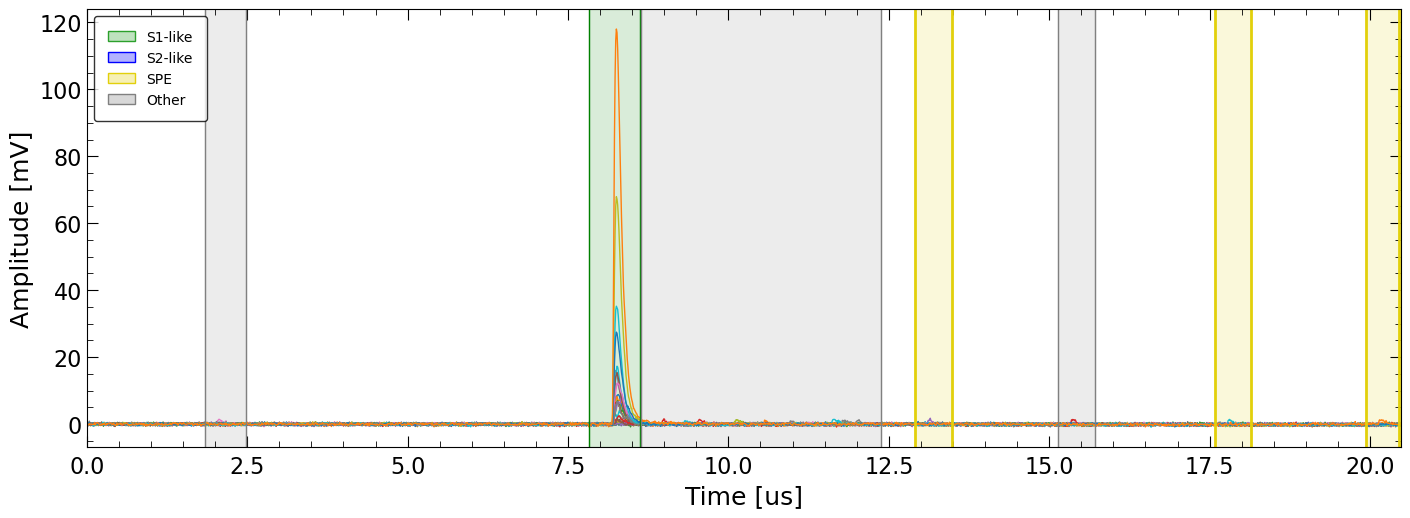

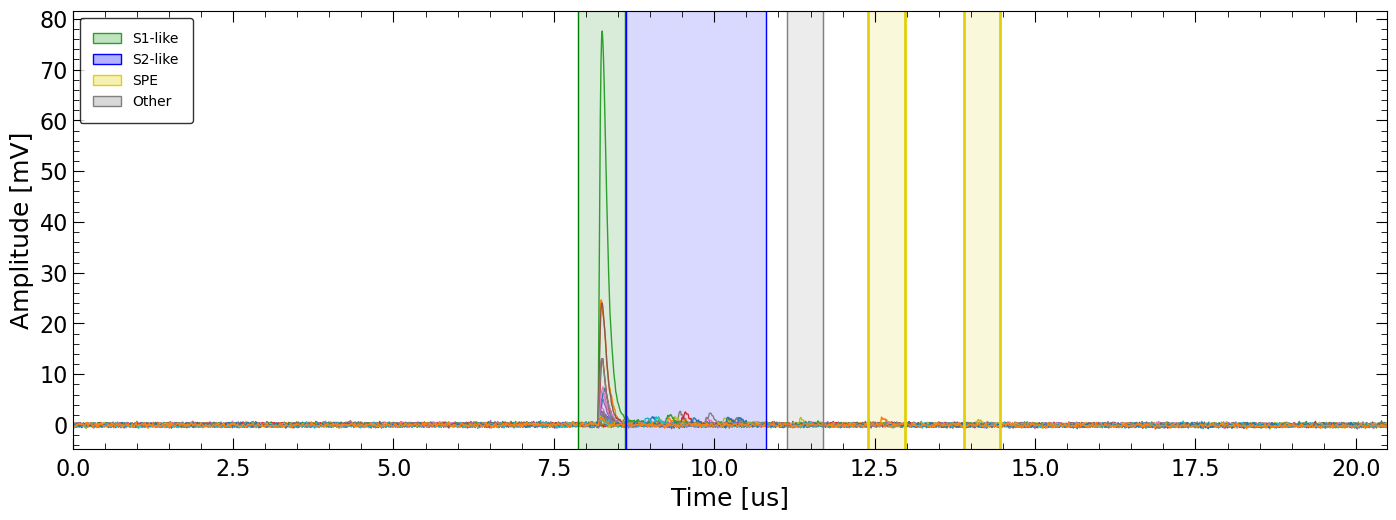

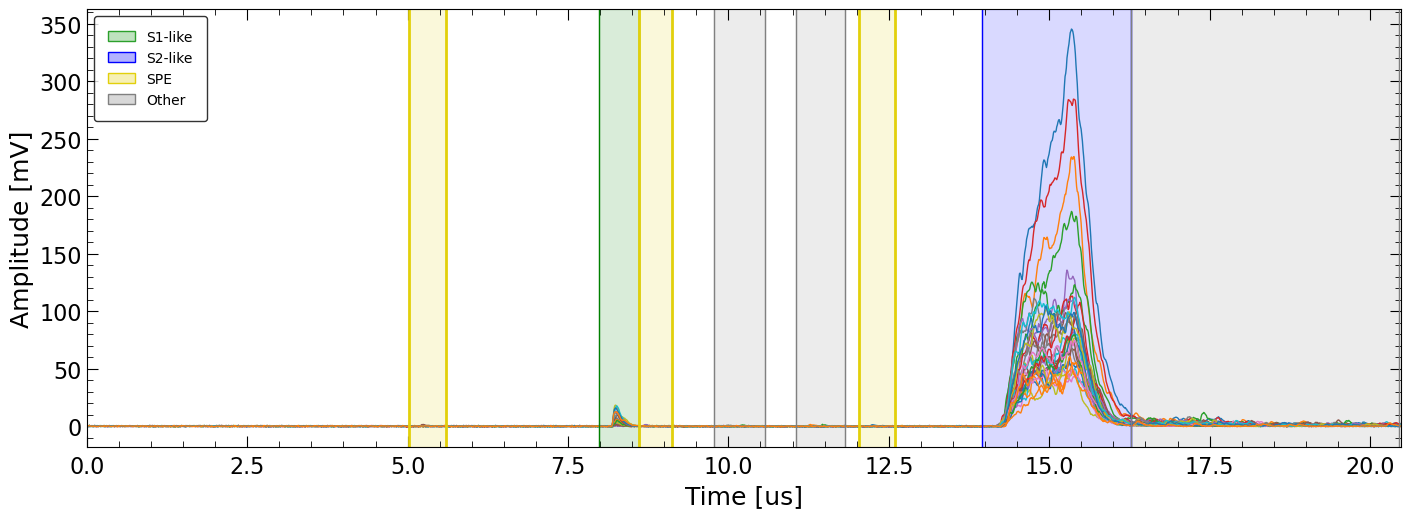

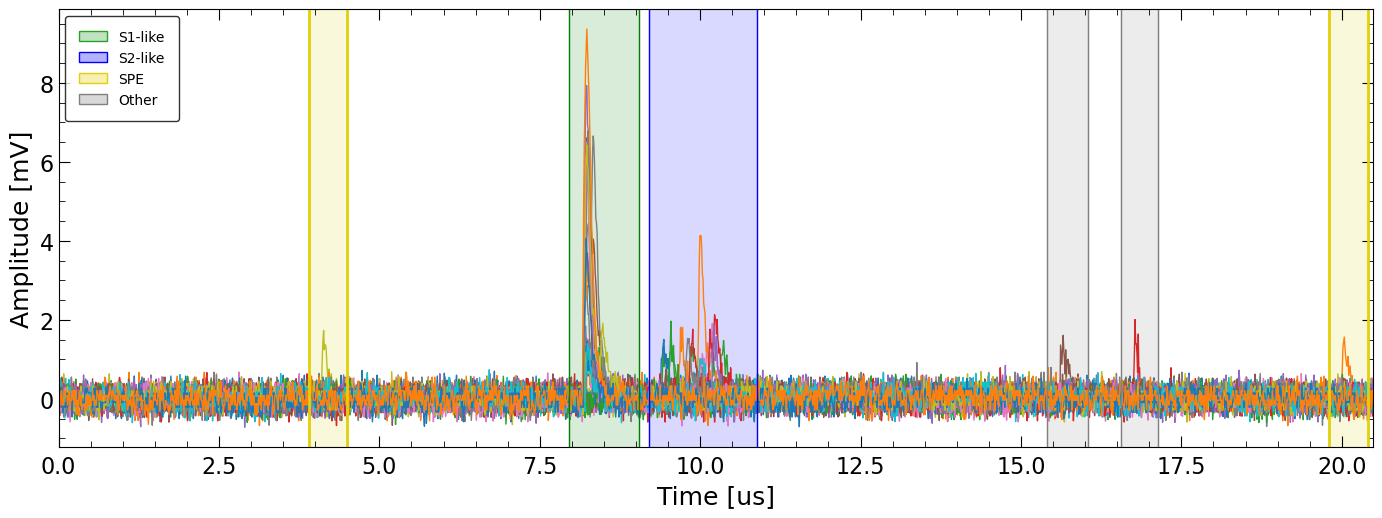

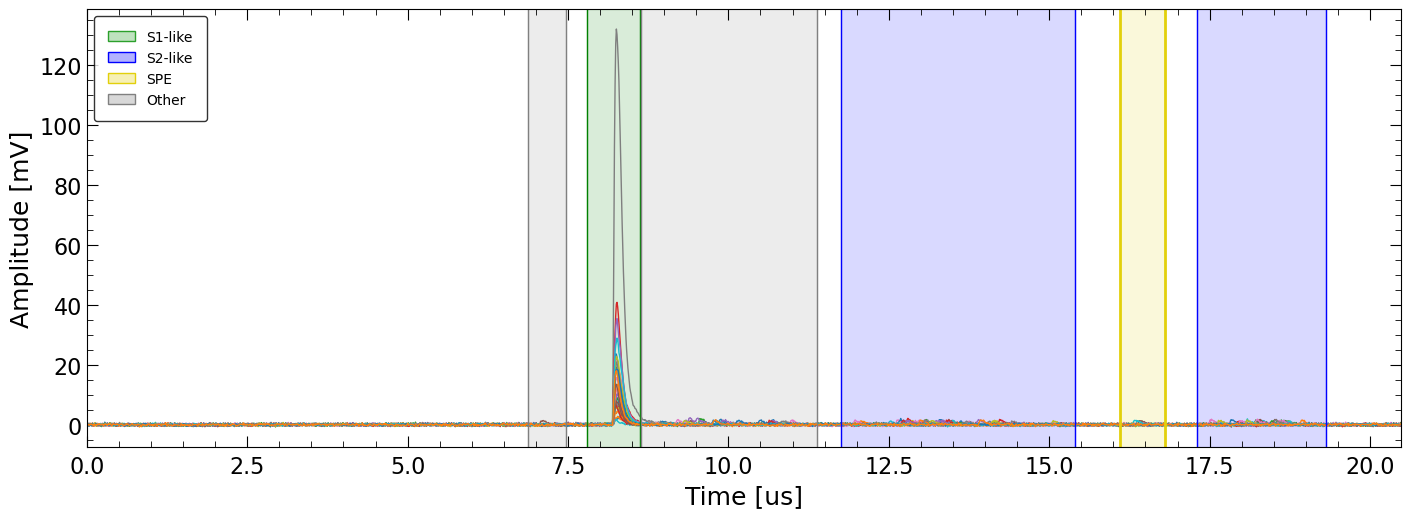

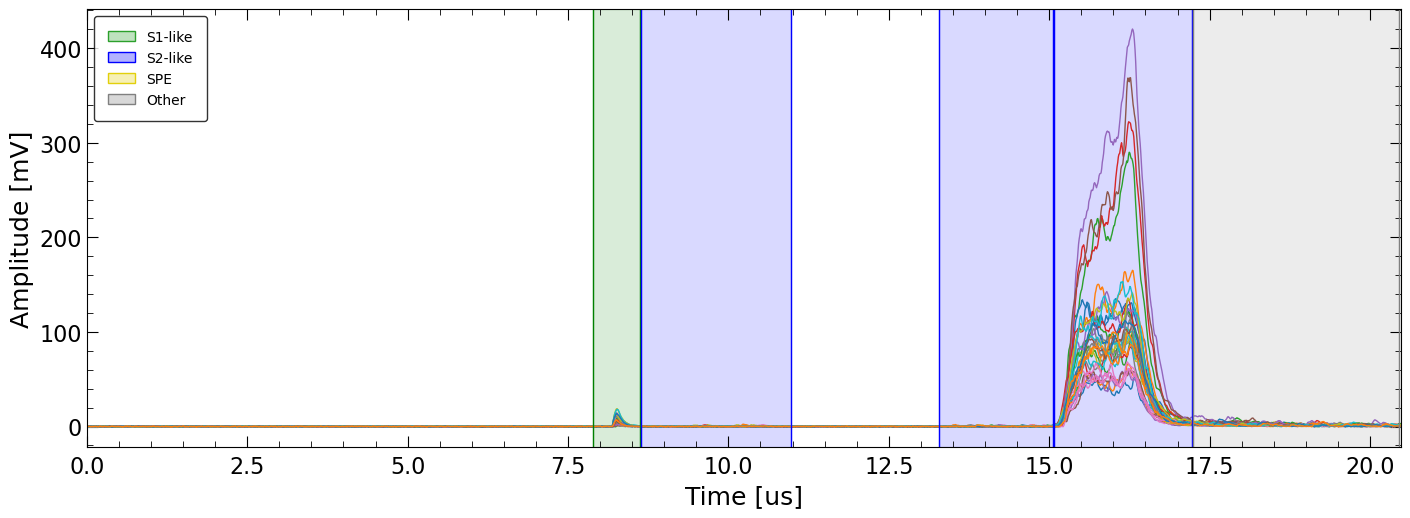

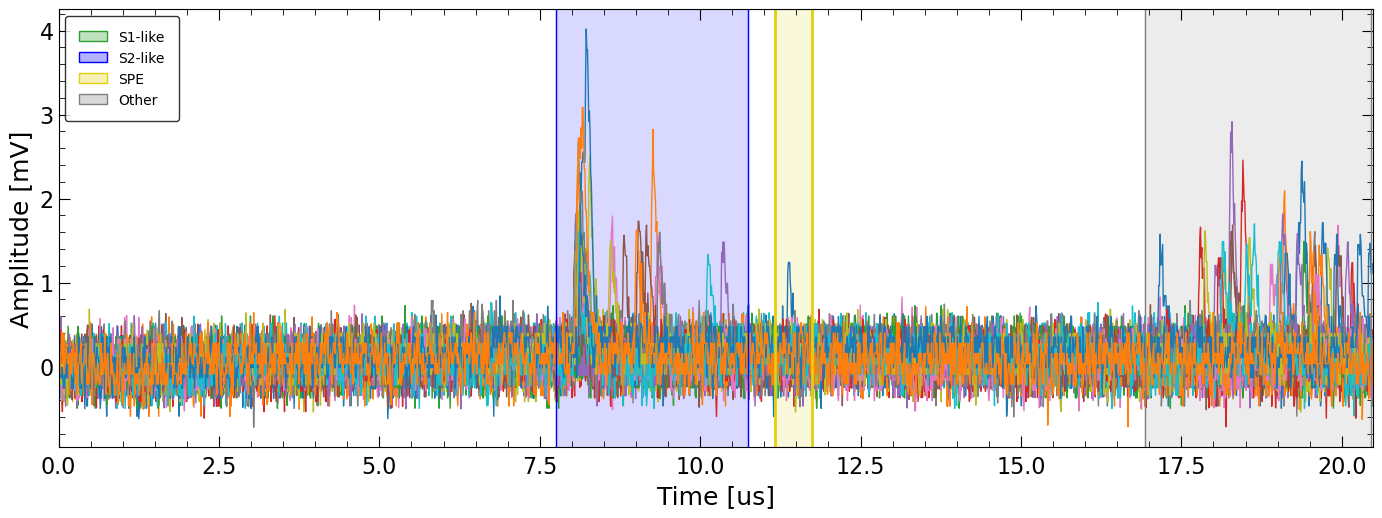

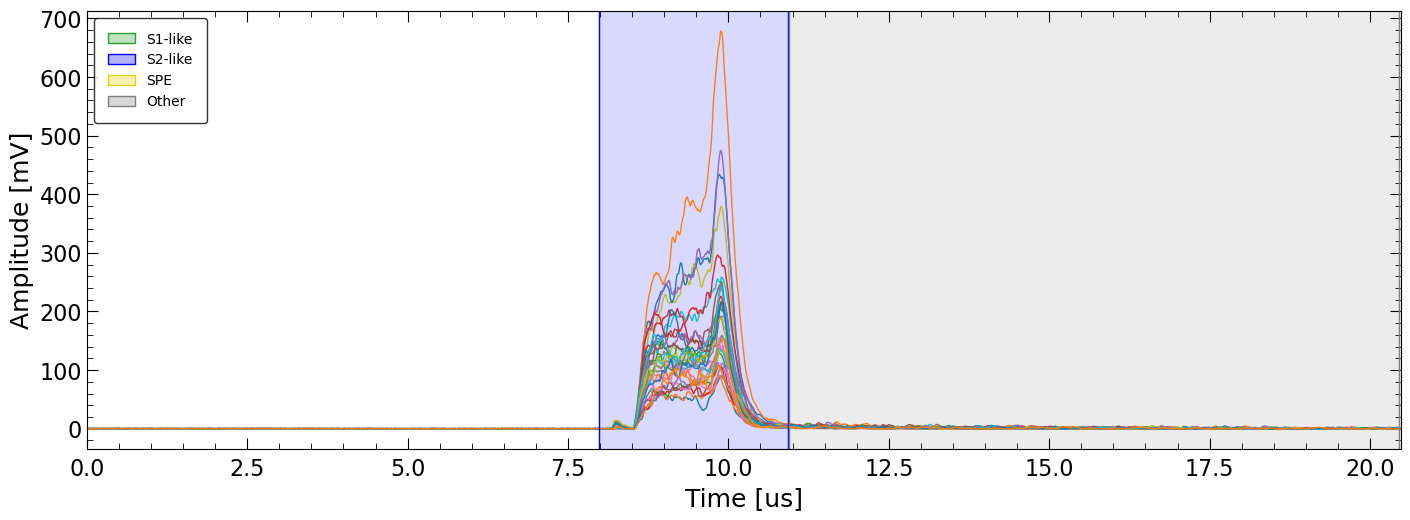

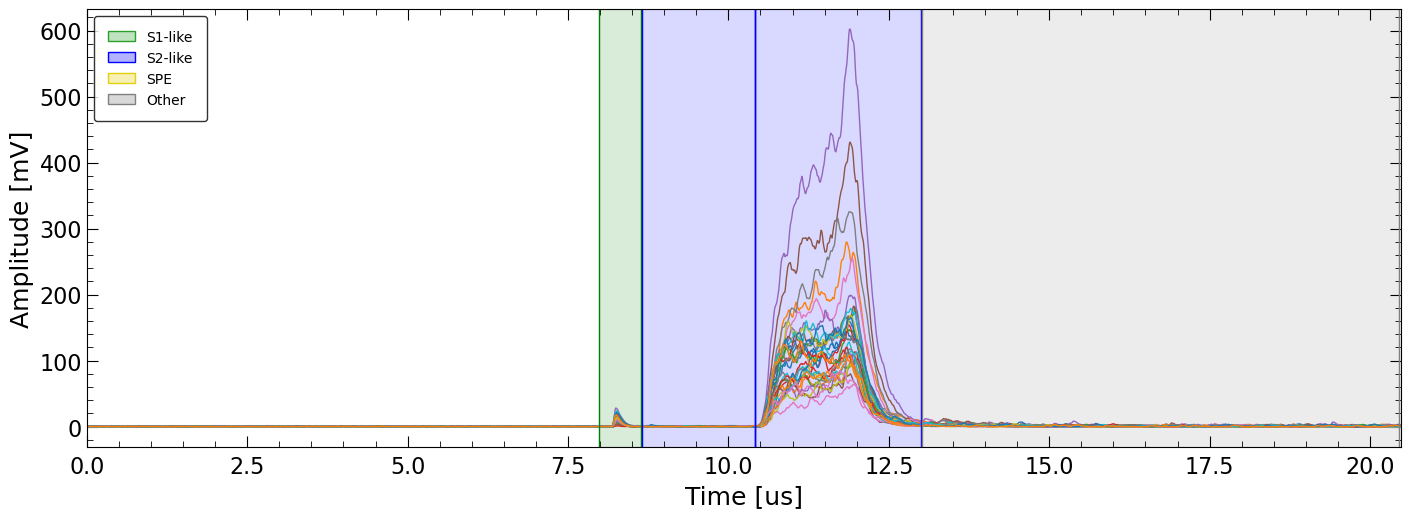

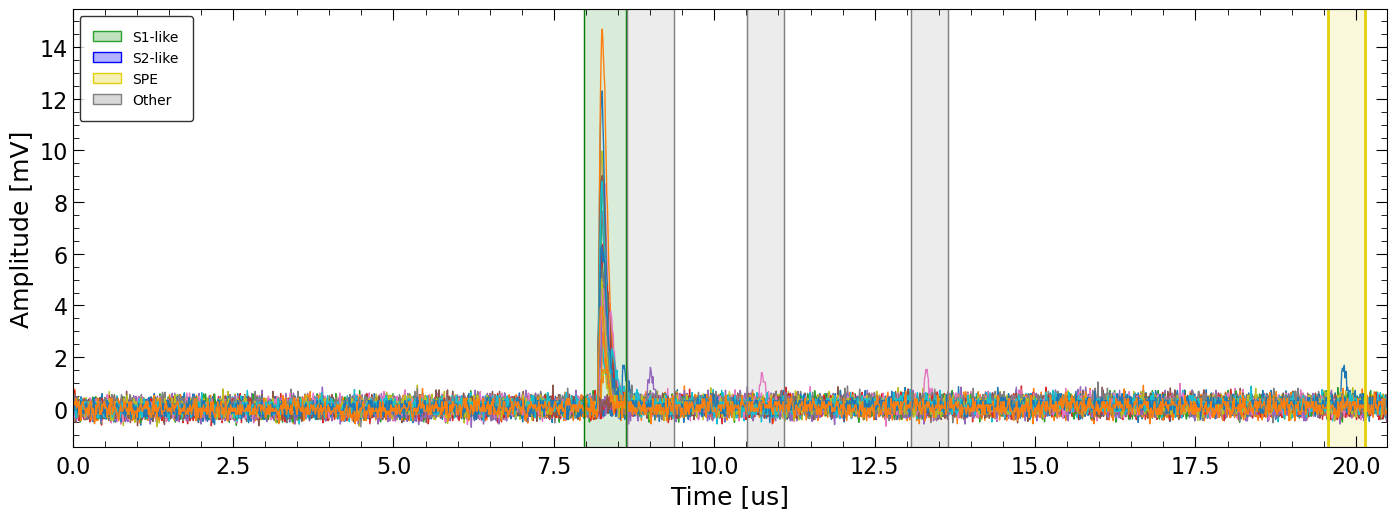

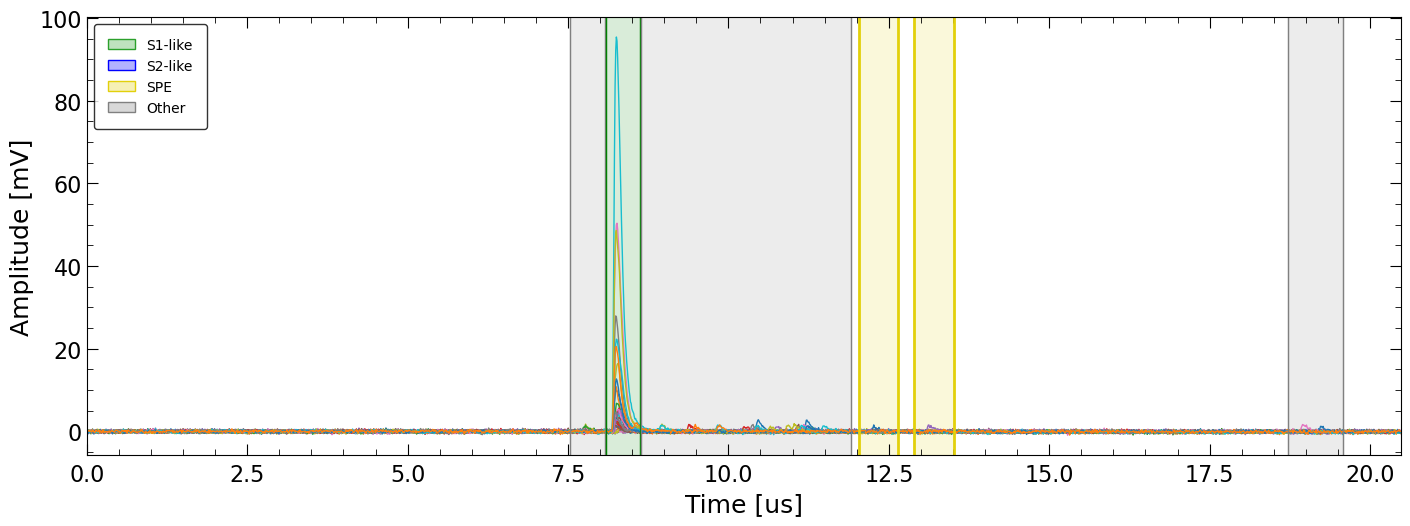

In [12]:
for l in range(14000, 20000, 100):
    k = int(l)
    plt.figure(figsize=(18,6))
    for i in range(32):
        plt.plot(np.linspace(0, 20.48, 2048), (d[k, i, :] - np.mean(d[k, i, 0:100]))*10**3/2**13, linewidth=1.0)
        plt.xlabel("Time [us]")
        plt.ylabel("Amplitude [mV]")

    for j in range(len(pulseTypes[k])):
        if pulseTypes[k,j] == 1: #s1-like
            plt.axvline(x=pulseBnds[k,0,j][0]/100, color='green', lw=1)
            plt.axvline(x=pulseBnds[k,1,j][0]/100, color='green', lw=1)
            plt.axvspan(pulseBnds[k,0,j][0]/100, pulseBnds[k,1,j][0]/100, color='green', alpha=0.15)
        elif pulseTypes[k,j] == 2: #s2-like
                plt.axvline(x=pulseBnds[k,0,j][0]/100, color='blue', lw=1)
                plt.axvline(x=pulseBnds[k,1,j][0]/100, color='blue', lw=1)
                plt.axvspan(pulseBnds[k,0,j][0]/100, pulseBnds[k,1,j][0]/100, color='blue', alpha=0.15)
        elif pulseTypes[k,j] == 3: #spe
            plt.axvline(x=pulseBnds[k,0,j][0]/100, color="#E2D00B")
            plt.axvline(x=pulseBnds[k,1,j][0]/100, color='#E2D00B')
            plt.axvspan(pulseBnds[k,0,j][0]/100, pulseBnds[k,1,j][0]/100, color='#E2D00B', alpha=0.15)
        else: #other
            plt.axvline(x=pulseBnds[k,0,j][0]/100, color='gray', lw=1)
            plt.axvline(x=pulseBnds[k,1,j][0]/100, color='gray', lw=1)
            plt.axvspan(pulseBnds[k,0,j][0]/100, pulseBnds[k,1,j][0]/100, color='gray', alpha=0.15)

    inside_color = (0, 1, 0, 0.3)  

    border_color = (1, 0, 0, 1.0) 

    legend_elements = [
        mpatches.Patch(label='S1-like', facecolor=(0.1725, 0.6275, 0.1725, 0.3) , edgecolor=(0.1725, 0.6275, 0.1725, 1.0), linewidth=1),
        mpatches.Patch(label='S2-like', facecolor=(0, 0, 1, 0.3) , edgecolor=(0, 0, 1, 1.0), linewidth=1),
        mpatches.Patch(label='SPE', facecolor=(0.886, 0.816, 0.043, 0.3) , edgecolor=(0.886, 0.816, 0.043, 1.0), linewidth=1),
        mpatches.Patch(label='Other', facecolor=(0.5, 0.5, 0.5, 0.3) , edgecolor=(0.5, 0.5, 0.5, 1.0), linewidth=1),
    ]
    plt.xlim(0,20.48)
    plt.legend(handles=legend_elements, loc='upper left', frameon=True, edgecolor="black", borderpad=1)
    plt.show()